In [151]:
import pandas as pd
data = pd.read_csv('imputed_data.csv')
head = data.head()
head

,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,total_acc,loan_paid,has_imputed_values,monthly_income,payment_to_income_ratio,earliest_cr_line_date,credit_age_years,payment_ratio_to_loan,loan_to_income_ratio,fico_score
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,24.0,1,0,14166.666667,0.018606,2004-12-01,20.281999,0.032947,0.047059,739
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,27.0,1,0,6250.000000,0.067749,2003-11-01,21.366188,0.033210,0.170000,743
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,13.0,0,0,5000.000000,0.083916,2001-10-01,23.449692,0.034965,0.200000,662
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,18.0,1,0,4000.000000,0.133837,1997-08-01,27.616701,0.026767,0.416667,586
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,13.0,0,0,2083.333333,0.471658,1990-03-01,35.036277,0.032754,1.200000,503


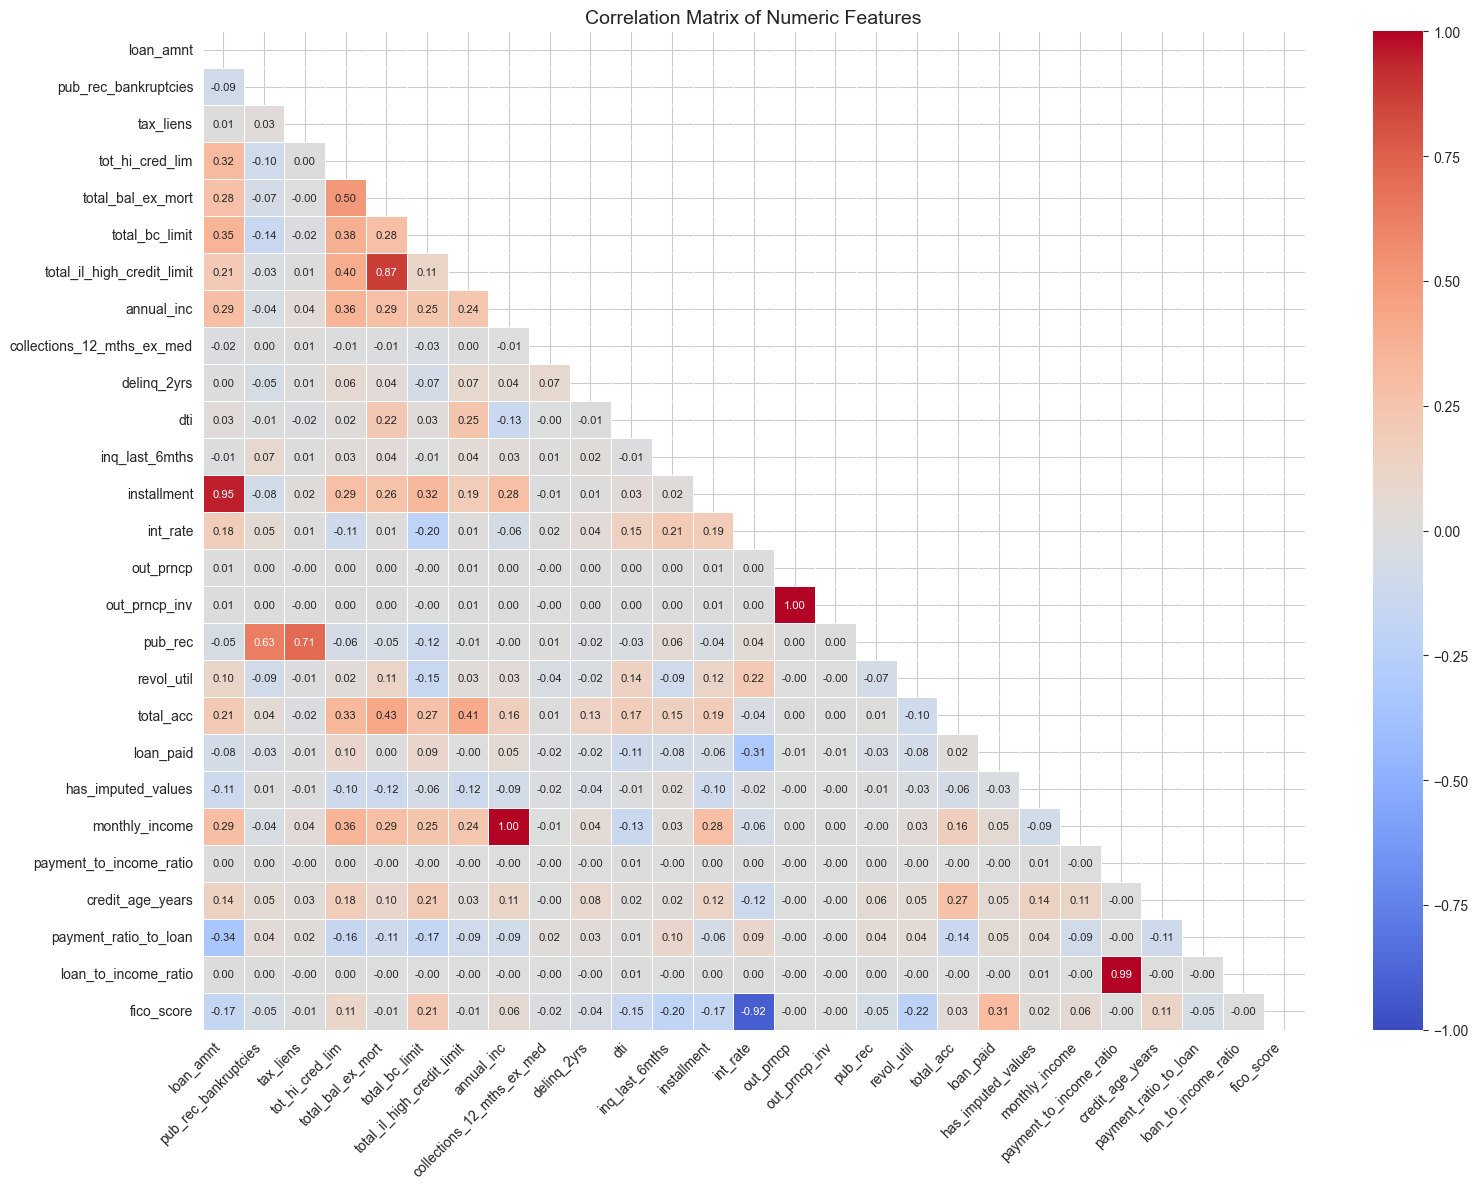

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Multicolinearity Analysis
# Create a correlation matrix of numeric variables 
cor_matrix = data.corr(numeric_only=True)

# Display a heatmap of the correlations with improved readability
plt.figure(figsize=(16, 12))  # Larger figure size
mask = np.triu(cor_matrix)    # Create a mask for the upper triangle
sns.heatmap(
    cor_matrix, 
    annot=True,               # Show correlation values
    cmap="coolwarm",          # Color scheme
    fmt=".2f",                # Format as 2 decimal places
    linewidths=0.5,           # Add lines between cells
    annot_kws={"size": 8},    # Increase annotation text size
    mask=mask,                # Apply mask to show only lower triangle
    vmin=-1, vmax=1           # Fix color scale
)
plt.xticks(rotation=45, ha='right')  # Rotate x labels for better readability
plt.yticks(rotation=0)               # Keep y labels horizontal
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.tight_layout()                   # Adjust layout to fit everything
plt.show()

In [153]:
import pandas as pd
import numpy as np
from datetime import datetime

# Create the four requested features
def create_features(df):
    # 1. Payment to income ratio
    # HAD ISSUE WITH MONTHLY INCOME BEING 0 SO 
# Replace both zeros and NaNs with median value
    median_income = df['monthly_income'].replace(0, np.nan).median()
    df['monthly_income'] = df['monthly_income'].replace(0, median_income)
    
    # Handle annual income
    median_annual_inc = df['annual_inc'].replace(0, np.nan).median()
    df['annual_inc'] = df['annual_inc'].replace(0, median_annual_inc)
    
    # Create log transformation of annual income to address skewness
    df['log_annual_inc'] = np.log1p(df['annual_inc'])
    
    # 2. Credit age (in years)
    # Convert earliest_cr_line to datetime and calculate age
    df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
    current_date = datetime.now()
    df['credit_age_years'] = ((current_date - df['earliest_cr_line_date']).dt.days / 365.25)
    
    # 4. Loan amount to income ratio
    df['loan_to_income_ratio'] = df['loan_amnt'] / df['annual_inc']
    
    # Create dummy variables for home ownership
    df['home_ownership_RENT'] = (df['home_ownership'] == 'RENT').astype(int)
    df['home_ownership_MORTGAGE'] = (df['home_ownership'] == 'MORTGAGE').astype(int)
    # Extract the numeric part from the term string and convert to integer
    df["term_months"] = df.term.str.extract('(\d+)').astype(int)

    # Calculate effective monthly payment and round to 2 decimal places
    df["effective_pmt"] = (df.loan_amnt/df["term_months"]).round(2)
    
    # Calculate payment to income ratio
    df["payment_to_inc"] = df["effective_pmt"] / df["monthly_income"]
    
    # Create log transformation of payment to income ratio to address skewness
    df['log_payment_to_inc'] = np.log1p(df['payment_to_inc'])
    
    # Create log transformation of dti to address skewness
    df['log_dti'] = np.log1p(df['dti'])
    
    return df

# Apply the function
data = create_features(data)

<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chris\AppData\Local\Temp\ipykernel_56632\4288113208.py:33: SyntaxWarning: invalid escape sequence '\d'
  df["term_months"] = df.term.str.extract('(\d+)').astype(int)


In [154]:
# # Save df to CSV with UTF-8 encoding
# data.to_csv('feature_data.csv', index=False, encoding='utf-8')

# # Verify the file was created
# import os
# print(f"File saved to: {os.getcwd()}/feature_data.csv")
# print(f"File exists: {os.path.exists('feature_data.csv')}")
# print(f"File size: {os.path.getsize('feature_data.csv') / (1024*1024):.2f} MB")

data.isnull().sum()

loan_amnt                     0
verification_status           0
pub_rec_bankruptcies          0
tax_liens                     0
tot_hi_cred_lim               0
total_bal_ex_mort             0
total_bc_limit                0
total_il_high_credit_limit    0
disbursement_method           0
debt_settlement_flag          0
annual_inc                    0
collections_12_mths_ex_med    0
delinq_2yrs                   0
dti                           0
grade                         0
earliest_cr_line              0
emp_length                    0
home_ownership                0
inq_last_6mths                0
installment                   0
int_rate                      0
last_pymnt_d                  0
out_prncp                     0
out_prncp_inv                 0
pub_rec                       0
purpose                       0
revol_util                    0
term                          0
total_acc                     0
loan_paid                     0
has_imputed_values            0
monthly_

# Apply Process of Feature Selection
- sort feature by business purpose and var type
- univariate analysis (continous var)
- univariate analysis (categorical var)
- IV calc
- Mulitollinearity Check
- VIF calc

In [155]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Try to import statsmodels, or install it if missing
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    print("Installing statsmodels package...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

In [156]:
# Load the data (replace with your actual data path)
df = data

# Check data shape and basic info
print(f"Dataset shape: {df.shape}")
print("\nSample of the data:")
display(df.head())

# Verify target variable
print("\nTarget variable distribution:")
print(df['loan_paid'].value_counts(normalize=True))

# Calculate the baseline default rate (percentage of loans not paid)
baseline_defaultrate = df['loan_paid'].value_counts(normalize=True)[0]
print(f"\nBaseline Default Rate: {baseline_defaultrate:.4f} ({baseline_defaultrate*100:.2f}%)")
print(f"Baseline Repayment Rate: {1-baseline_defaultrate:.4f} ({(1-baseline_defaultrate)*100:.2f}%)")

Dataset shape: (210000, 46)

Sample of the data:


,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,loan_to_income_ratio,fico_score,log_annual_inc,home_ownership_RENT,home_ownership_MORTGAGE,term_months,effective_pmt,payment_to_inc,log_payment_to_inc,log_dti
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,0.047059,739,12.043560,0,0,36,222.22,0.015686,0.015564,1.717395
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,0.170000,743,11.225257,1,0,36,354.17,0.056667,0.055120,3.494688
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,0.200000,662,11.002117,1,0,36,333.33,0.066666,0.064538,2.227862
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,0.416667,586,10.778977,0,0,60,333.33,0.083332,0.080042,2.327278
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,1.200000,503,10.126671,1,0,60,500.00,0.240000,0.215111,4.130516



Target variable distribution:
loan_paid
0    0.500152
1    0.499848
Name: proportion, dtype: float64

Baseline Default Rate: 0.5002 (50.02%)
Baseline Repayment Rate: 0.4998 (49.98%)


In [157]:
# Step 1: Business-Driven Initial Selection
# Categorize variables by business function as defined in the documentation

# I REMOVED LC OUTPUT VS# ANALYZING THE CONTINOUS VARS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# proportion_of_defaults: This shows what percentage of all defaults across the entire dataset occur in each decile. It answers "Where are the defaults concentrated?"
# default_rate: This would show the percentage of observations within each decile that defaulted. It answers "How risky is this decile?"
def analyze_by_deciles(df, var, target):
    # Create deciles
    df_decile = df[[var, target]].copy()
    
    try:
        # First create the bins without labels to see how many we get
        temp_decile = pd.qcut(df[var], 10, duplicates='drop')
        num_bins = temp_decile.cat.categories.size
        
        # Now create the deciles with the correct number of labels
        df_decile['decile'] = pd.qcut(df[var], num_bins, labels=range(1, num_bins+1), duplicates='drop')
        
        # Get the bin edges to understand what each decile represents
        bin_edges = pd.qcut(df[var], num_bins, duplicates='drop', retbins=True)[1]
        
        # Create range labels for each decile
        range_labels = []
        for i in range(len(bin_edges)-1):
            range_labels.append(f"{bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}")
        
        # Calculate statistics by decile
        decile_stats = df_decile.groupby('decile').agg(
            count=pd.NamedAgg(column=target, aggfunc='count'),
            num_defaults=pd.NamedAgg(column=target, aggfunc='sum')
        )
        
        # Calculate proportion of total defaults
        total_defaults = decile_stats['num_defaults'].sum()
        decile_stats['proportion_of_defaults'] = decile_stats['num_defaults'] / total_defaults
        decile_stats['default_rate'] = decile_stats['num_defaults'] / decile_stats['count']

        # Add the range information to the statistics
        decile_stats['range'] = range_labels
        
        # Print decile information
        print(f"\nDecile Statistics for {var} ({num_bins} bins created):")
        for i, row in decile_stats.iterrows():
            print(f"Decile {i}: {row['range']} - Count: {row['count']}, "
                    f"Number of Defaults: {row['num_defaults']}, "
                    f"Default Rate: {row['default_rate']:.2%}, "
                    f"Proportion of Total Defaults: {row['proportion_of_defaults']:.2%}")
        
        # Plot
        plt.figure(figsize=(12, 7))
        ax = sns.barplot(x=decile_stats.index.astype(str), y='proportion_of_defaults', data=decile_stats)
        plt.title(f"Proportion of Total Defaults by Decile for {var}")
        plt.xlabel("Decile (Higher = Higher Values)")
        plt.ylabel("Proportion of Total Defaults")
        
        # Add labels to the bars
        for i, p in enumerate(ax.patches):
            ax.annotate(f"{decile_stats['proportion_of_defaults'].iloc[i]:.2%}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom')
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        return decile_stats
        
    except Exception as e:
        print(f"Could not analyze {var} by deciles: {str(e)}")
        return None



# Financial Variables
financial_vars = [
    'loan_amnt', 'effective_pmt',
    'annual_inc', 'log_annual_inc', 'dti', 'total_acc', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'tot_hi_cred_lim', 'revol_util', 'payment_to_inc',
    'log_payment_to_inc', 'log_dti'
]

# Borrower Information Variables
borrower_info_vars = [
    'emp_length', 'home_ownership_RENT', 'home_ownership_MORTGAGE', 'credit_age_years', 'home_ownership',
]

# Credit History Variables
credit_history_vars = [
    'inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies',
    'delinq_2yrs',
]

# Loan Status Variables (excluding the target variable)
loan_status_vars = [
    'term', 'purpose', 'has_imputed_values'
]

# Target variable
target_var = 'loan_paid'

# Combine all predictor variables
all_predictors = financial_vars + borrower_info_vars + credit_history_vars + loan_status_vars

# Print the categories and the number of variables in each
print(f"Financial Variables ({len(financial_vars)}): {financial_vars}")
print(f"Borrower Information Variables ({len(borrower_info_vars)}): {borrower_info_vars}")
print(f"Credit History Variables ({len(credit_history_vars)}): {credit_history_vars}")
print(f"Loan Status Variables ({len(loan_status_vars)}): {loan_status_vars}")
print(f"Total Predictor Variables: {len(all_predictors)}")

Financial Variables (14): ['loan_amnt', 'effective_pmt', 'annual_inc', 'log_annual_inc', 'dti', 'total_acc', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'tot_hi_cred_lim', 'revol_util', 'payment_to_inc', 'log_payment_to_inc', 'log_dti']
Borrower Information Variables (5): ['emp_length', 'home_ownership_RENT', 'home_ownership_MORTGAGE', 'credit_age_years', 'home_ownership']
Credit History Variables (4): ['inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies', 'delinq_2yrs']
Loan Status Variables (3): ['term', 'purpose', 'has_imputed_values']
Total Predictor Variables: 26


In [158]:
# Helper function to check if a variable is numeric
def is_numeric(df, col):
    return pd.api.types.is_numeric_dtype(df[col])

# Identify continuous and categorical variables
# CHECKING FOR OVER 25 UNIQUE NUMERICAL VALUES. IF BELOW TEN THEN THAT SHIT IS CATEGORICAL LIKE THE NON NUMERIC VARS
continuous_vars = [col for col in all_predictors if is_numeric(df, col) and df[col].nunique() > 25]
categorical_vars = [col for col in all_predictors if col not in continuous_vars]

print(f"Continuous Variables ({len(continuous_vars)}):")
for var in continuous_vars:
    print(f"  - {var}")
    
print(f"\nCategorical Variables ({len(categorical_vars)}):")
for var in categorical_vars:
    print(f"  - {var}")

# Prepare a dictionary to store analysis results
analysis_results = {
    'correlation': {},
    'iv': {},
    'categorical_stats': {},
    'decile_stats': {}
}

Continuous Variables (15):
  - loan_amnt
  - effective_pmt
  - annual_inc
  - log_annual_inc
  - dti
  - total_acc
  - total_bal_ex_mort
  - total_bc_limit
  - total_il_high_credit_limit
  - tot_hi_cred_lim
  - revol_util
  - payment_to_inc
  - log_payment_to_inc
  - log_dti
  - credit_age_years

Categorical Variables (11):
  - emp_length
  - home_ownership_RENT
  - home_ownership_MORTGAGE
  - home_ownership
  - inq_last_6mths
  - pub_rec
  - pub_rec_bankruptcies
  - delinq_2yrs
  - term
  - purpose
  - has_imputed_values



Analyzing loan_amnt:
Correlation with loan_paid: -0.0781
Correlation with default: 0.0781
As loan_amnt increases, default risk increases

Decile Statistics for loan_amnt (10 bins created):
Decile 1: 1000.00 to 5000.00
  Count: 26113
  Defaults: 11299 (43.27%)
  Paid Loans: 14814 (56.73%)
  Proportion of Total Defaults: 10.76%
Decile 2: 5000.00 to 7000.00
  Count: 17304
  Defaults: 7522 (43.47%)
  Paid Loans: 9782 (56.53%)
  Proportion of Total Defaults: 7.16%
Decile 3: 7000.00 to 9450.00
  Count: 19610
  Defaults: 8904 (45.41%)
  Paid Loans: 10706 (54.59%)
  Proportion of Total Defaults: 8.48%
Decile 4: 9450.00 to 10625.00
  Count: 21017
  Defaults: 10264 (48.84%)
  Paid Loans: 10753 (51.16%)
  Proportion of Total Defaults: 9.77%
Decile 5: 10625.00 to 12900.00
  Count: 20977
  Defaults: 10679 (50.91%)
  Paid Loans: 10298 (49.09%)
  Proportion of Total Defaults: 10.17%
Decile 6: 12900.00 to 15000.00
  Count: 21547
  Defaults: 10949 (50.81%)
  Paid Loans: 10598 (49.19%)
  Proportion of 

C:\Users\chris\AppData\Local\Temp\ipykernel_56632\79937698.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


Could not analyze loan_amnt by deciles: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

Analyzing effective_pmt:
Correlation with loan_paid: 0.0091
Correlation with default: -0.0091
As effective_pmt increases, default risk decreases

Decile Statistics for effective_pmt (10 bins created):
Decile 1: 16.67 to 138.89
  Count: 26485
  Defaults: 11522 (43.50%)
  Paid Loans: 14963 (56.50%)
  Proportion of Total Defaults: 10.97%
Decile 2: 138.89 to 177.78
  Count: 15658
  Defaults: 7757 (49.54%)
  Paid Loans: 7901 (50.46%)
  Proportion of Total Defaults: 7.39%
Decile 3: 177.78 to 222.22
  Count: 25866
  Defaults: 13370 (51.69%)
  Paid Loans: 12496 (48.31%)
  Proportion of Total Defaults: 12.73%
Decile 4: 222.22 to 266.67
  Count: 20408
  Defaults: 11442 (56.07%)
  Paid Loans: 8966 (43.93%)
  Proportion of Total Defaults: 10.89%
Decile 5: 

C:\Users\chris\AppData\Local\Temp\ipykernel_56632\79937698.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


Could not analyze effective_pmt by deciles: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

Analyzing annual_inc:
Correlation with loan_paid: 0.0527
Correlation with default: -0.0527
As annual_inc increases, default risk decreases


...


Decile Statistics for revol_util (10 bins created):
Decile 1: 0.00 to 19.80
  Count: 21155
  Defaults: 8612 (40.71%)
  Paid Loans: 12543 (59.29%)
  Proportion of Total Defaults: 8.20%
Decile 2: 19.80 to 30.80
  Count: 21017
  Defaults: 9477 (45.09%)
  Paid Loans: 11540 (54.91%)
  Proportion of Total Defaults: 9.02%
Decile 3: 30.80 to 39.10
  Count: 21035
  Defaults: 10106 (48.04%)
  Paid Loans: 10929 (51.96%)
  Proportion of Total Defaults: 9.62%
Decile 4: 39.10 to 46.60
  Count: 20822
  Defaults: 10438 (50.13%)
  Paid Loans: 10384 (49.87%)
  Proportion of Total Defaults: 9.94%
Decile 5: 46.60 to 53.70
  Count: 21247
  Defaults: 10705 (50.38%)
  Paid Loans: 10542 (49.62%)
  Proportion of Total Defaults: 10.19%
Decile 6: 53.70 to 60.60
  Count: 20876
  Defaults: 10910 (52.26%)
  Paid Loans: 9966 (47.74%)
  Proportion of Total Defaults: 10.39%
Decile 7: 60.60 to 67.90
  Count: 21103
  Defaults: 11088 (52.54%)
  Paid Loans: 10015 (47.46%)
  Proportion of Total Defaults: 10.56%
Decile 8: 

C:\Users\chris\AppData\Local\Temp\ipykernel_56632\79937698.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(
C:\Users\chris\AppData\Local\Temp\ipykernel_56632\79937698.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for log_payment_to_inc (10 bins created):
Decile 1: 0.00 to 0.02
  Count: 21002
  Defaults: 8214 (39.11%)
  Paid Loans: 12788 (60.89%)
  Proportion of Total Defaults: 7.82%
Decile 2: 0.02 to 0.03
  Count: 21007
  Defaults: 9431 (44.89%)
  Paid Loans: 11576 (55.11%)
  Proportion of Total Defaults: 8.98%
Decile 3: 0.03 to 0.04
  Count: 20996
  Defaults: 10036 (47.80%)
  Paid Loans: 10960 (52.20%)
  Proportion of Total Defaults: 9.56%
Decile 4: 0.04 to 0.05
  Count: 21027
  Defaults: 10375 (49.34%)
  Paid Loans: 10652 (50.66%)
  Proportion of Total Defaults: 9.88%
Decile 5: 0.05 to 0.06
  Count: 20992
  Defaults: 10667 (50.81%)
  Paid Loans: 10325 (49.19%)
  Proportion of Total Defaults: 10.16%
Decile 6: 0.06 to 0.06
  Count: 20976
  Defaults: 11074 (52.79%)
  Paid Loans: 9902 (47.21%)
  Proportion of Total Defaults: 10.54%
Decile 7: 0.06 to 0.07
  Count: 21000
  Defaults: 11496 (54.74%)
  Paid Loans: 9504 (45.26%)
  Proportion of Total Defaults: 10.95%
Decile 8: 0.07 t

C:\Users\chris\AppData\Local\Temp\ipykernel_56632\79937698.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for credit_age_years (10 bins created):
Decile 1: 9.73 to 17.73
  Count: 21103
  Defaults: 11700 (55.44%)
  Paid Loans: 9403 (44.56%)
  Proportion of Total Defaults: 11.14%
Decile 2: 17.73 to 19.81
  Count: 21541
  Defaults: 11633 (54.00%)
  Paid Loans: 9908 (46.00%)
  Proportion of Total Defaults: 11.08%
Decile 3: 19.81 to 21.48
  Count: 21647
  Defaults: 11537 (53.30%)
  Paid Loans: 10110 (46.70%)
  Proportion of Total Defaults: 10.98%
Decile 4: 21.48 to 22.98
  Count: 20395
  Defaults: 10446 (51.22%)
  Paid Loans: 9949 (48.78%)
  Proportion of Total Defaults: 9.95%
Decile 5: 22.98 to 24.48
  Count: 20776
  Defaults: 10299 (49.57%)
  Paid Loans: 10477 (50.43%)
  Proportion of Total Defaults: 9.81%
Decile 6: 24.48 to 26.14
  Count: 20875
  Defaults: 10149 (48.62%)
  Paid Loans: 10726 (51.38%)
  Proportion of Total Defaults: 9.66%
Decile 7: 26.14 to 28.39
  Count: 20958
  Defaults: 10108 (48.23%)
  Paid Loans: 10850 (51.77%)
  Proportion of Total Defaults: 9.62%
Deci

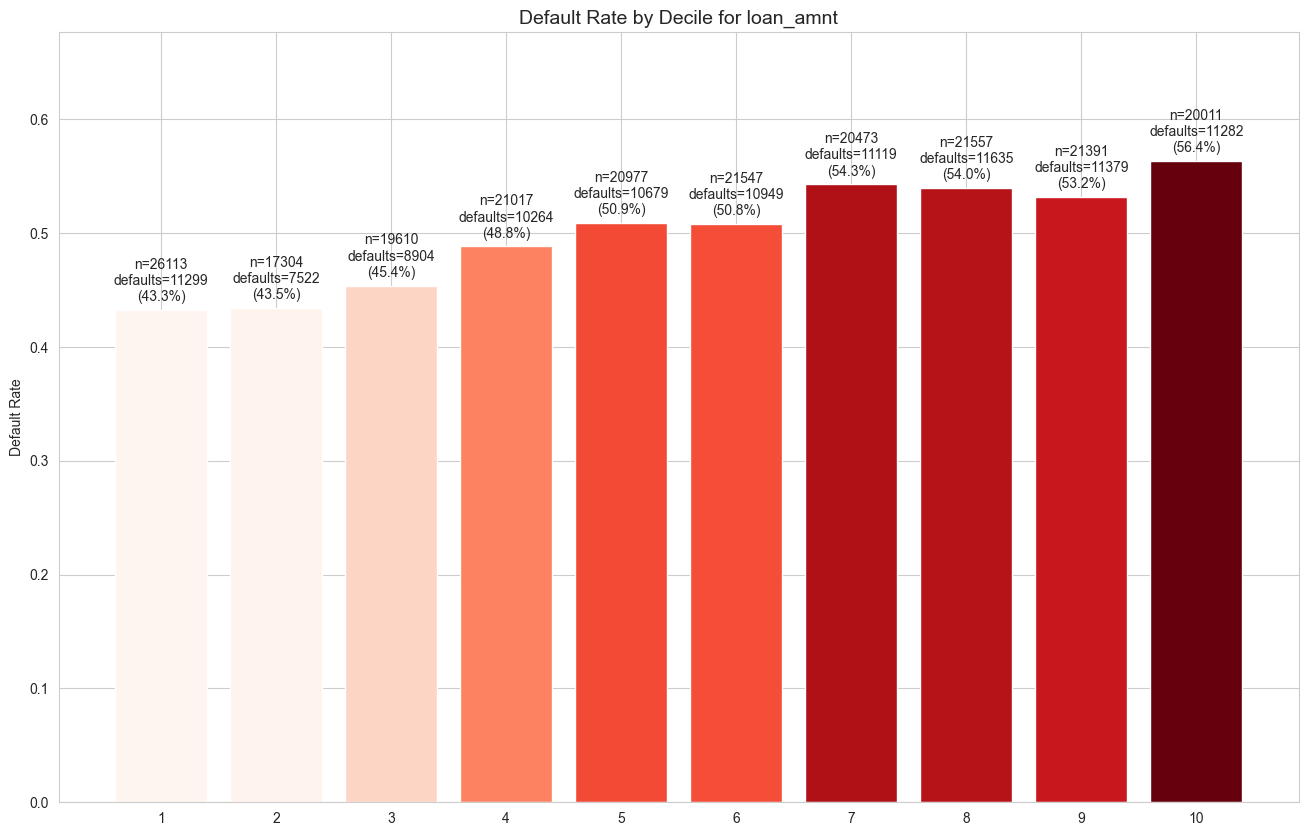

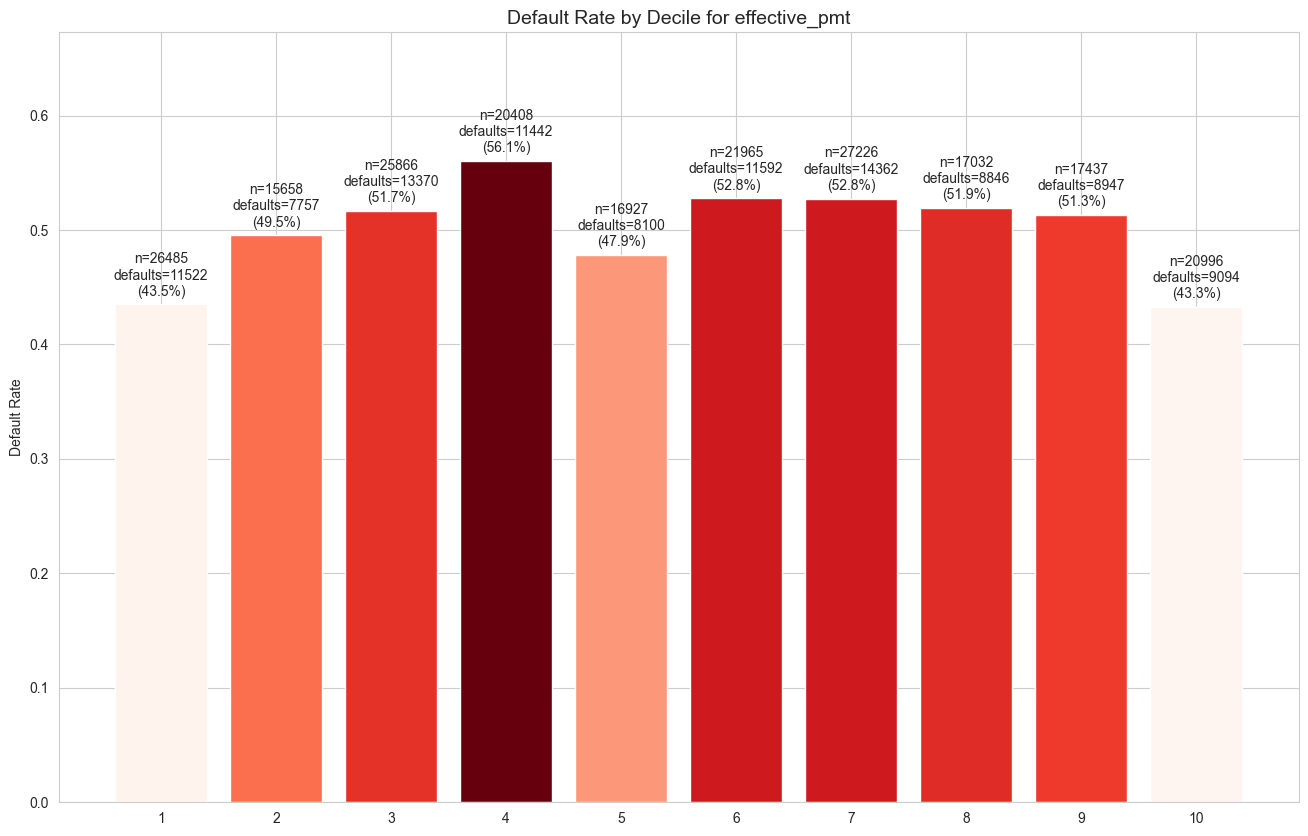

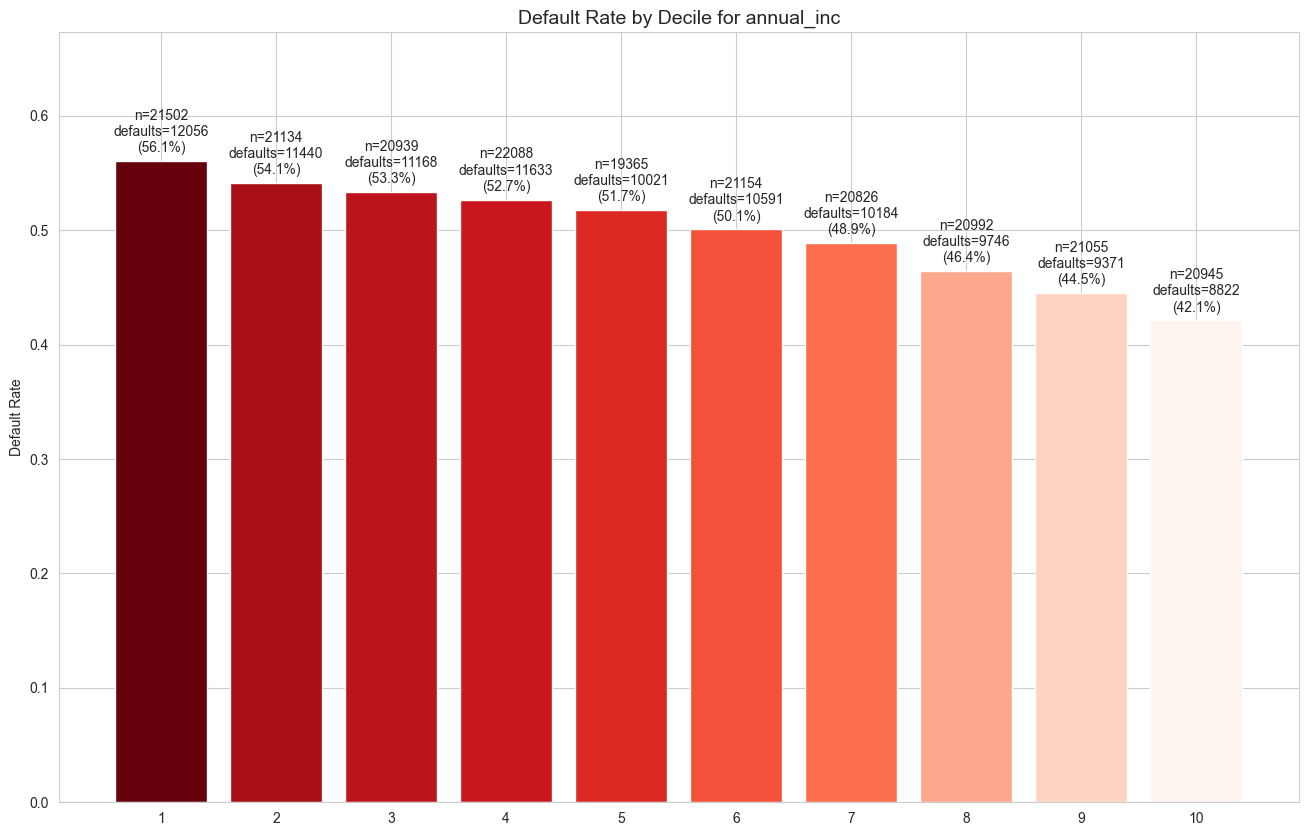

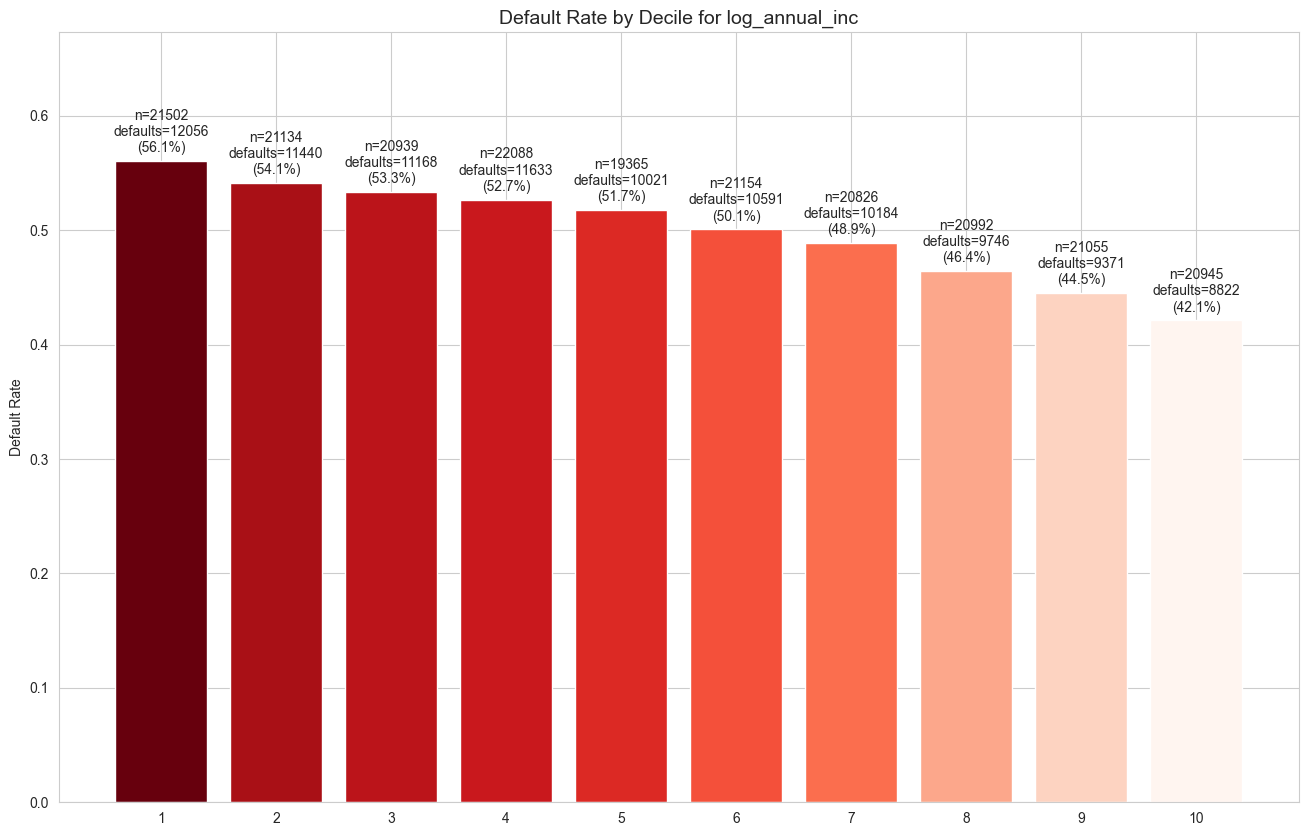

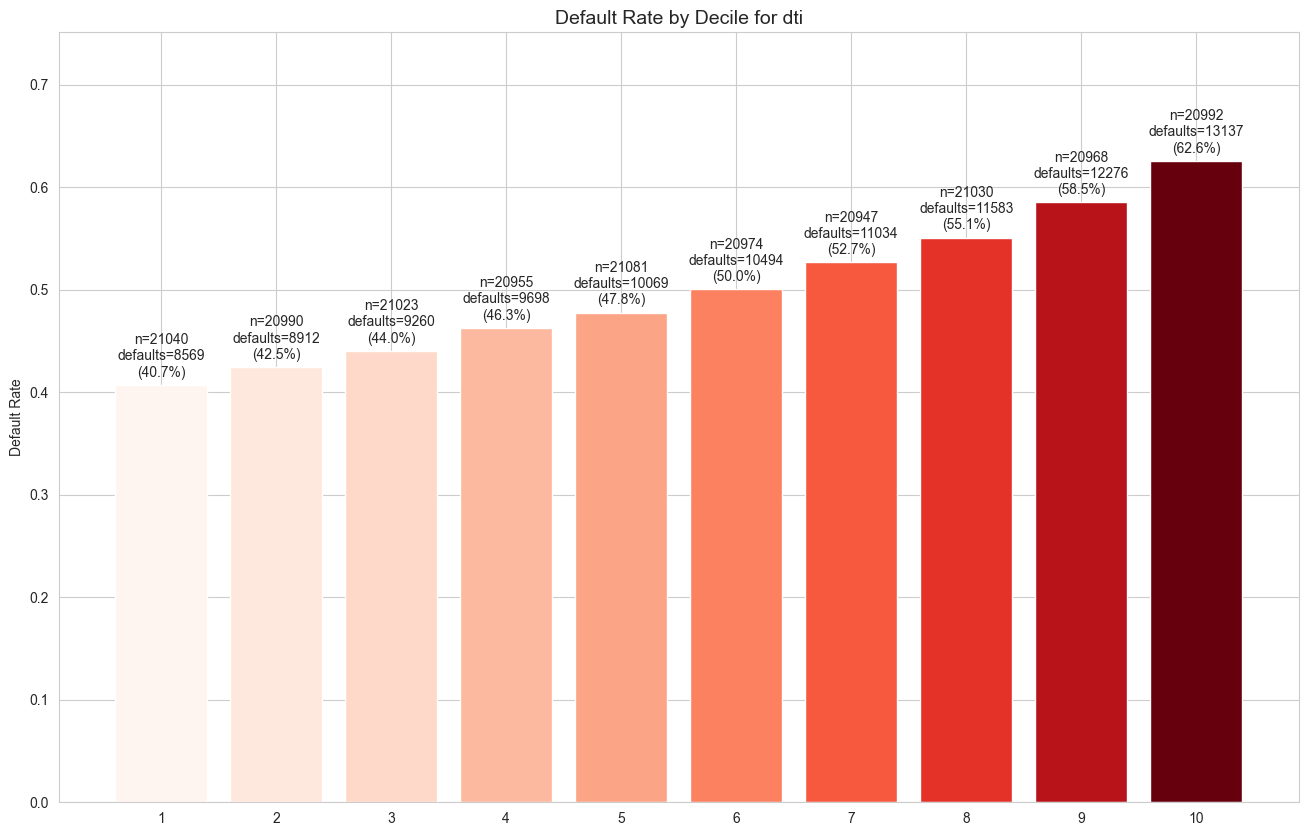

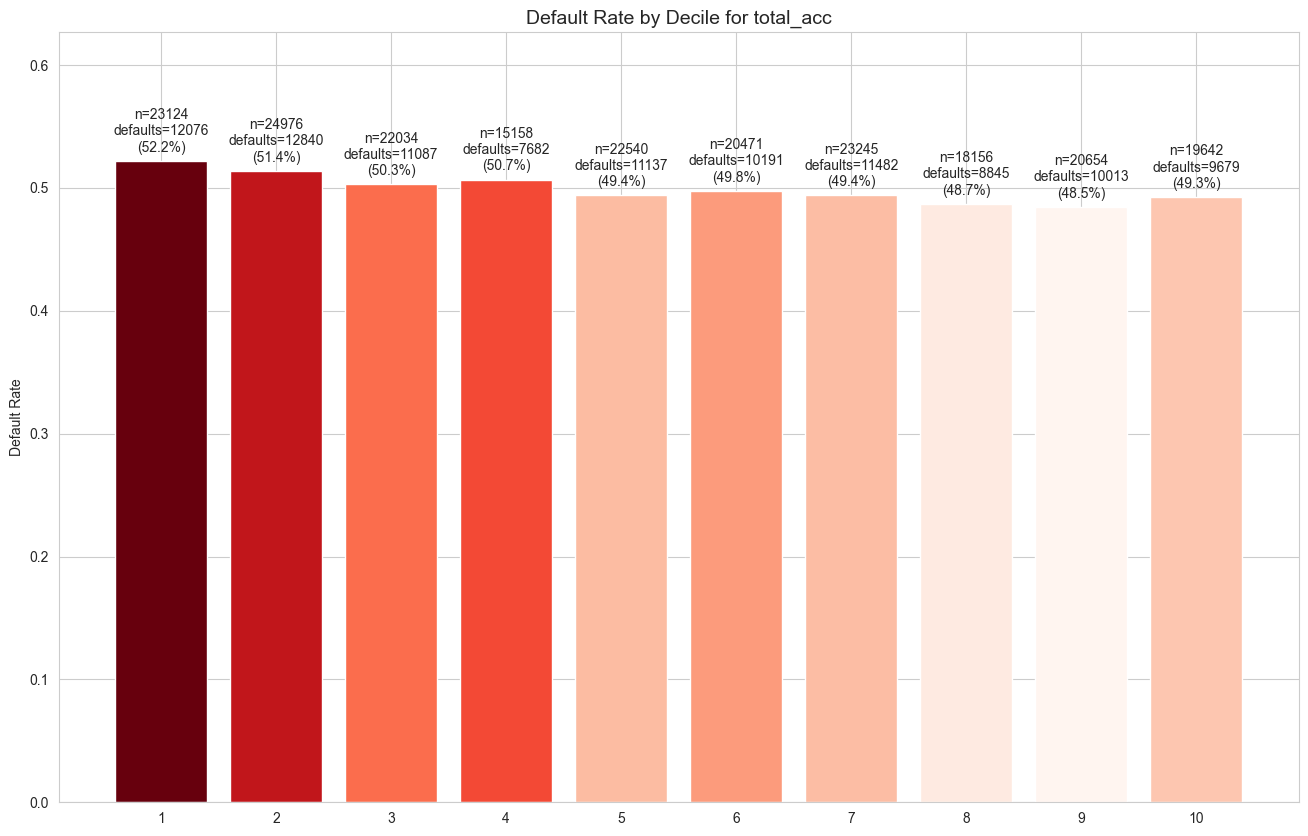

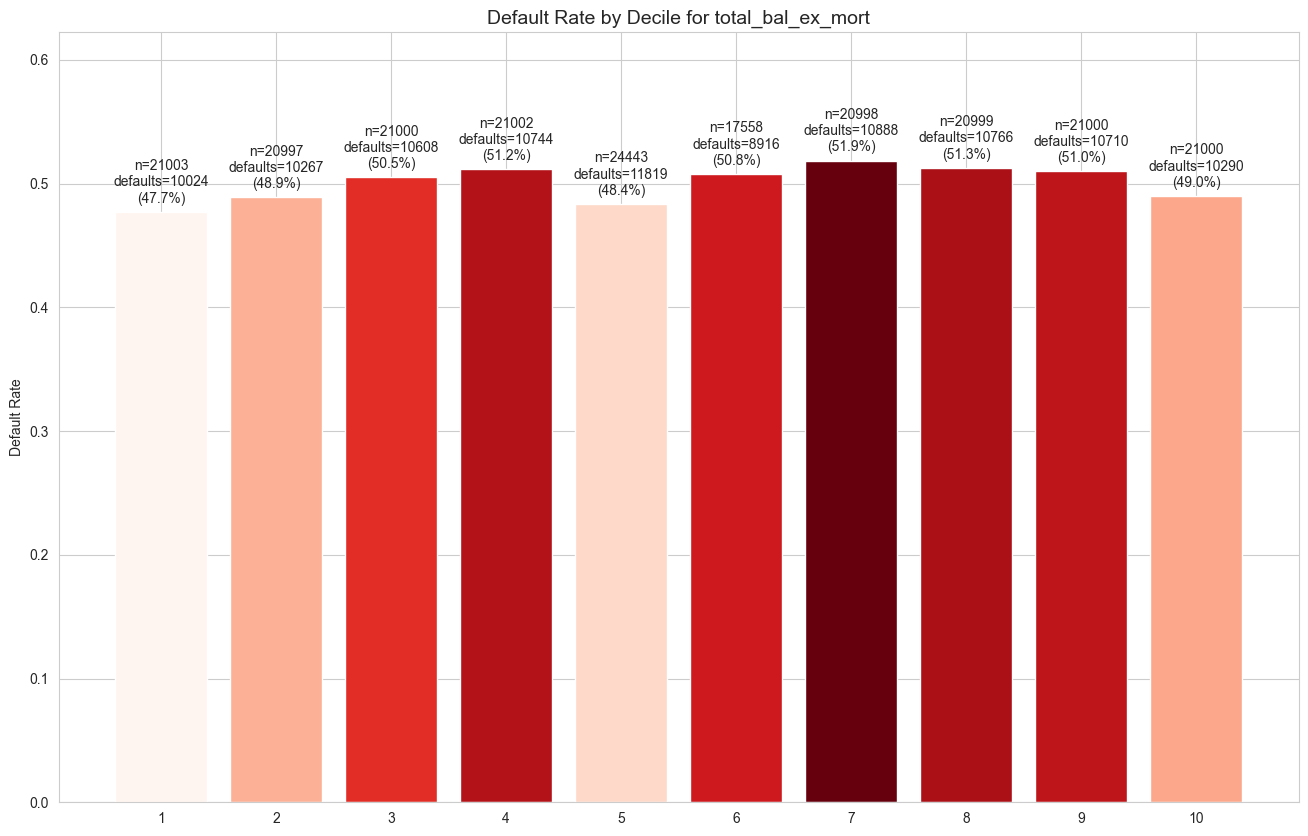

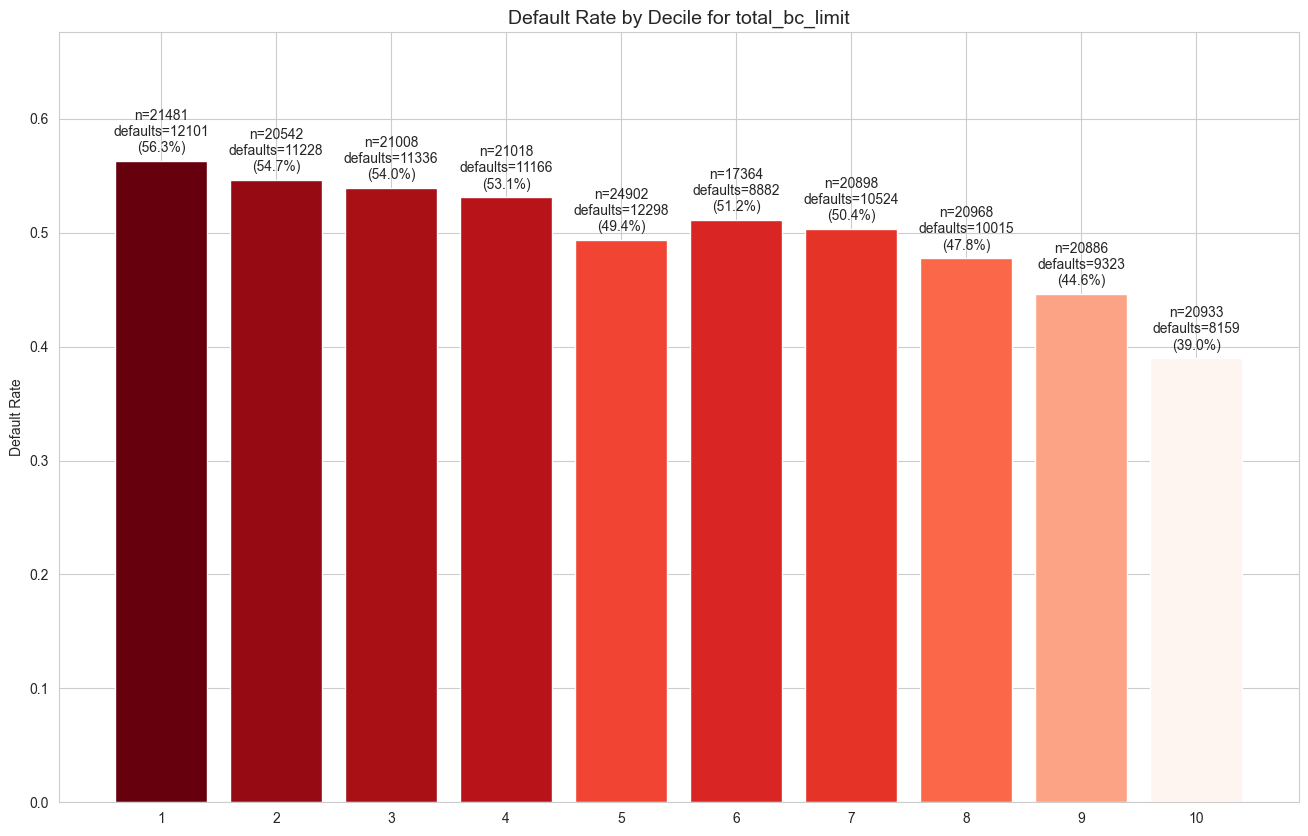

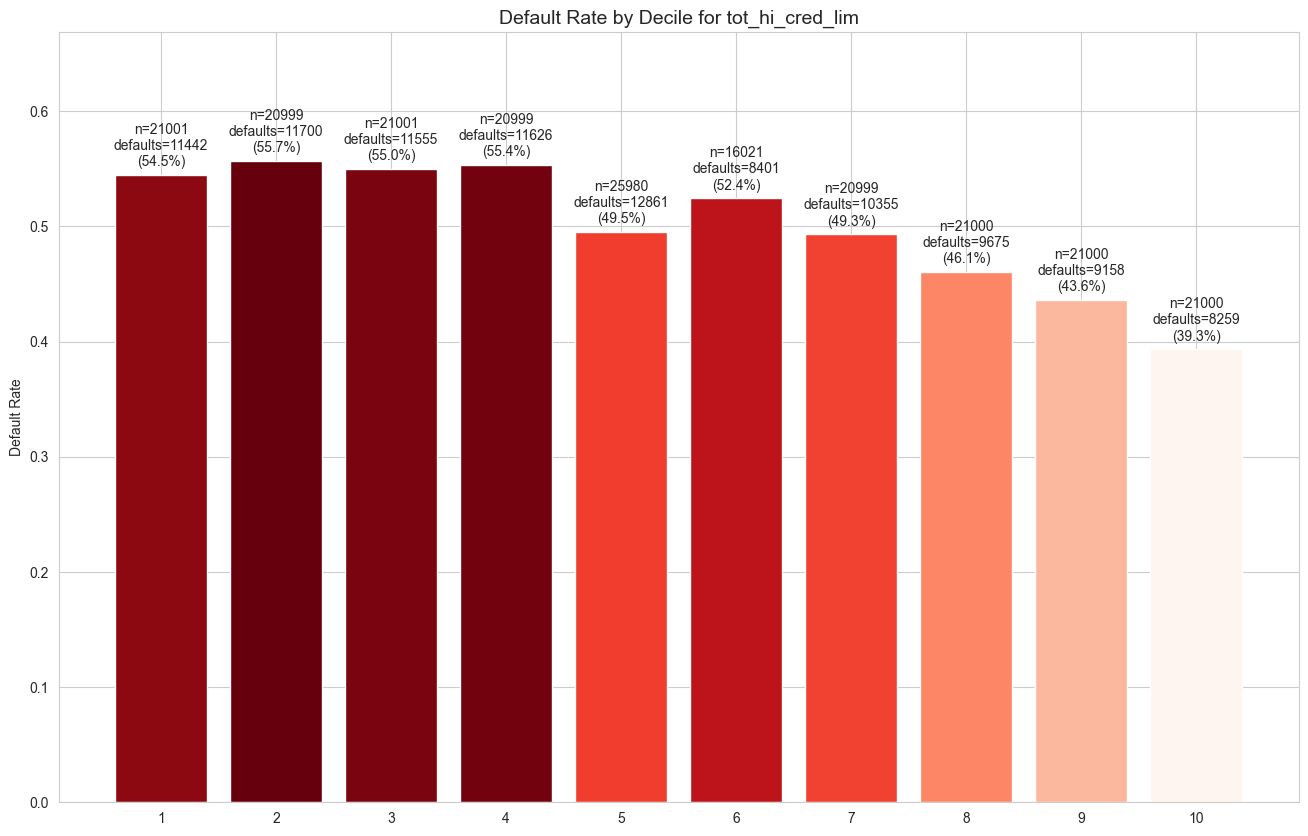

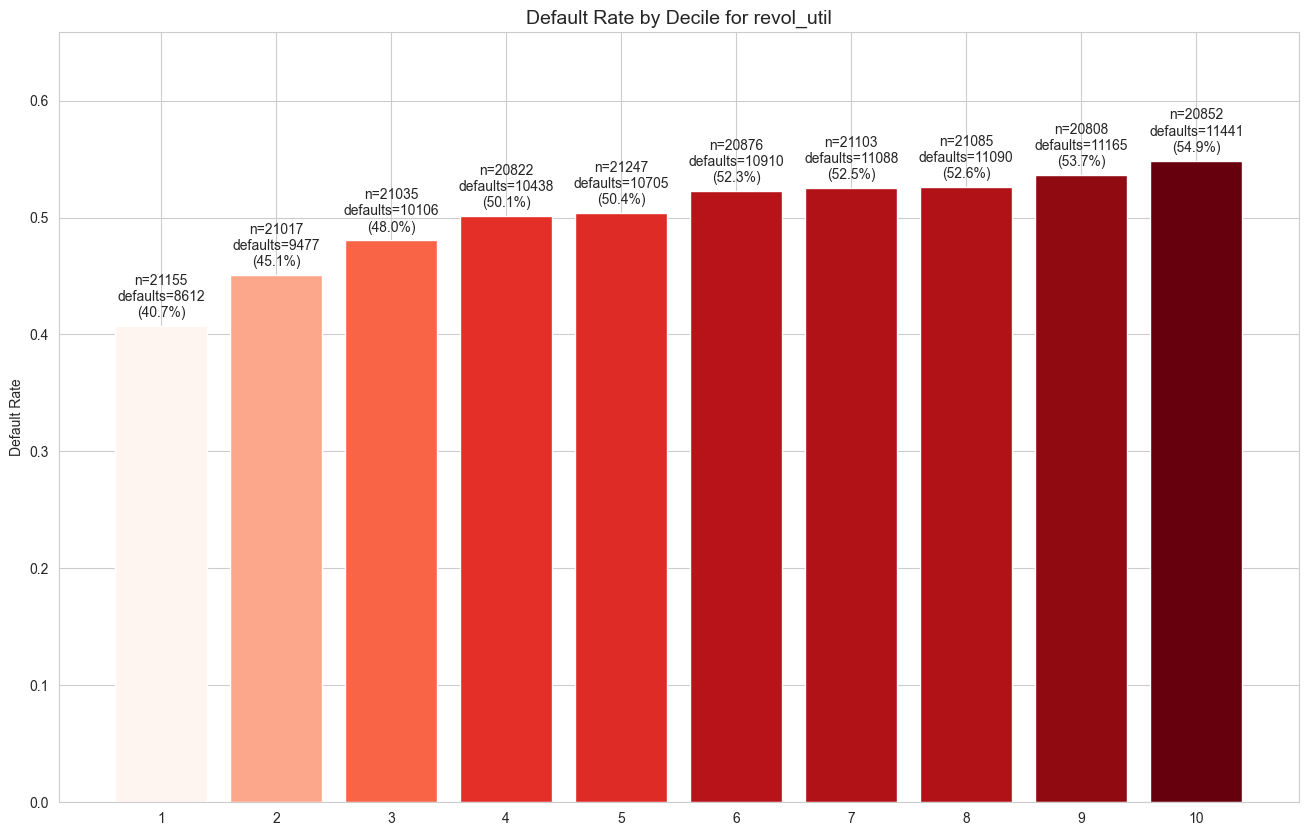

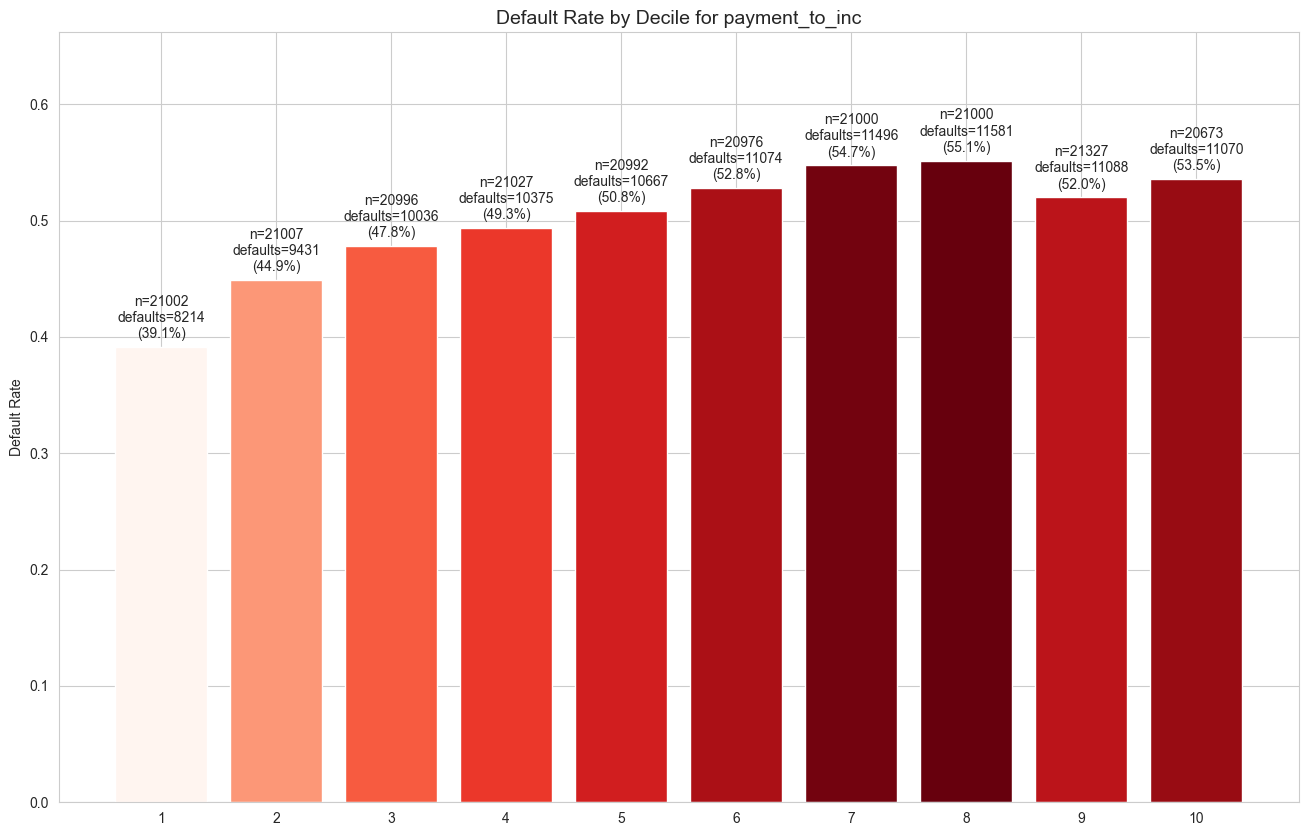

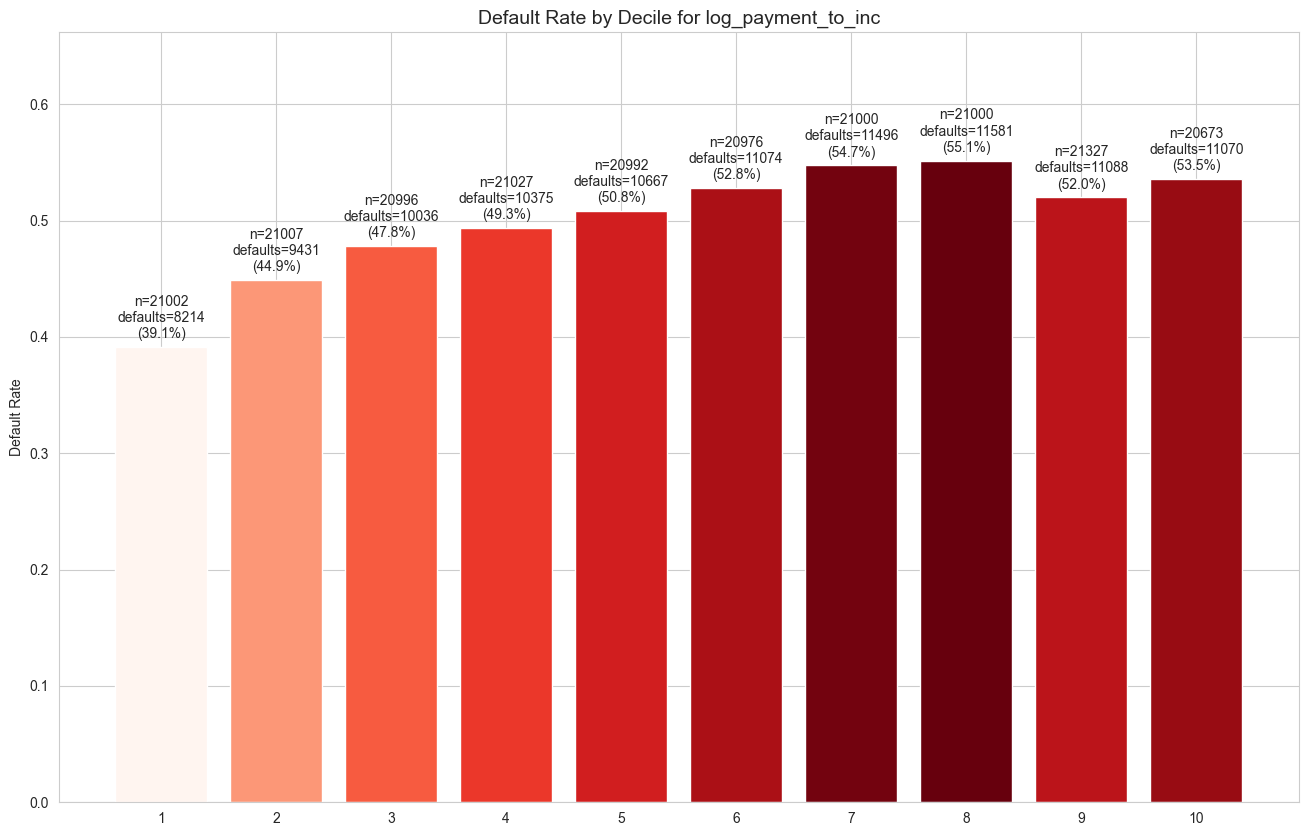

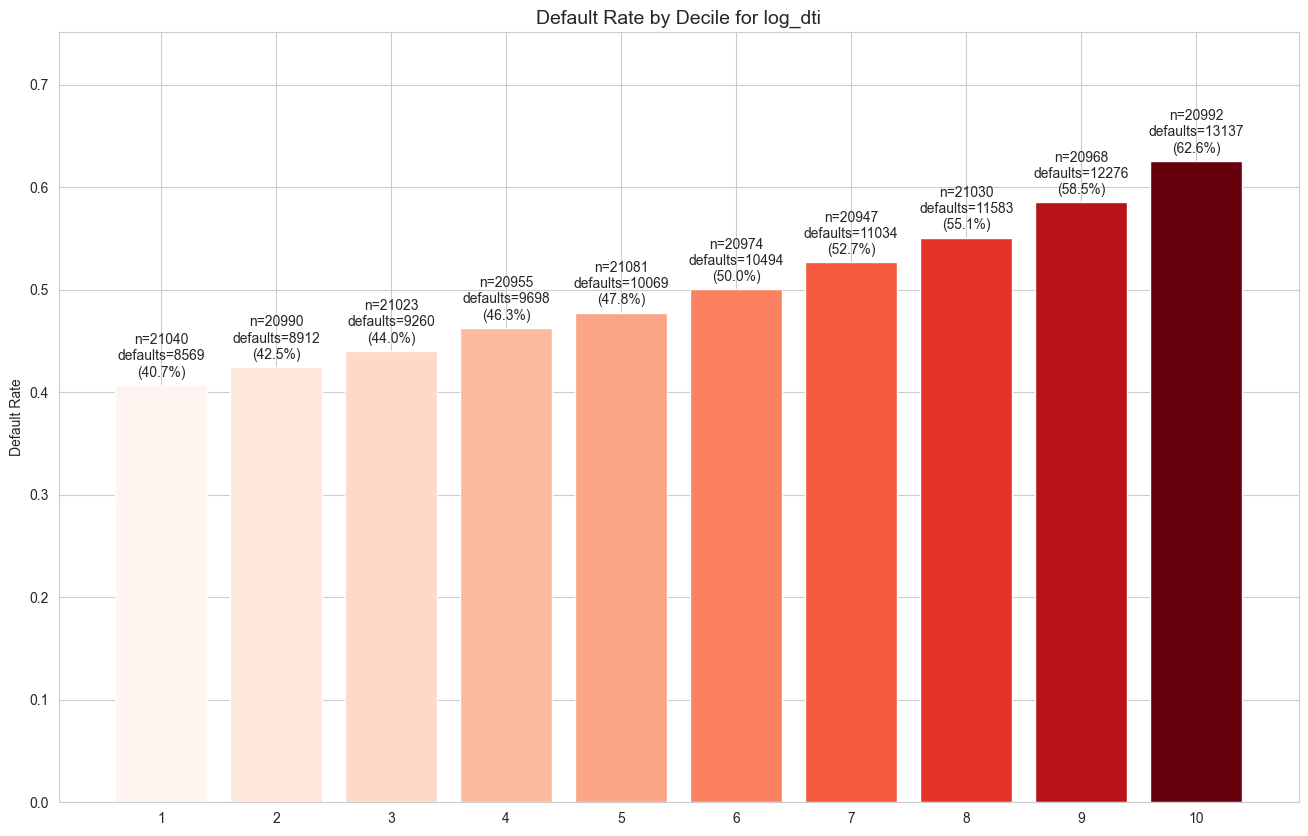

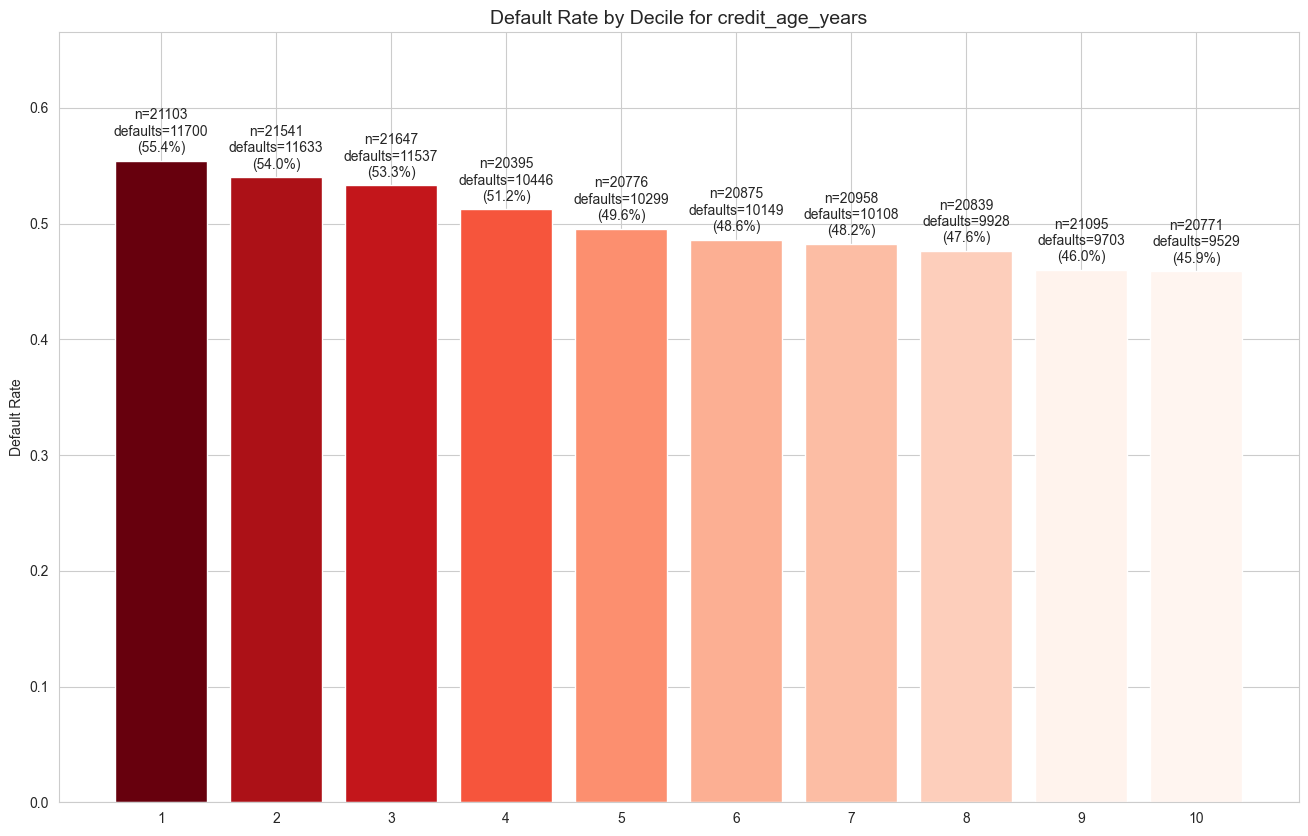

In [159]:
 # Improved function to analyze by deciles with clearer terminology
def analyze_by_deciles(df, var, target):
    """
    Analyze a variable by dividing it into deciles and examining the relationship with loan defaults.
    
    Args:
        df: DataFrame containing the data
        var: The variable to analyze
        target: The target variable (loan_paid where 1=paid, 0=default)
        
    Returns:
        DataFrame: Statistics by decile
    """
    # Create deciles
    df_decile = df[[var, target]].copy()
    
    try:
        # First create the bins without labels to see how many we get
        temp_decile = pd.qcut(df[var], 10, duplicates='drop')
        num_bins = temp_decile.cat.categories.size
        
        # Now create the deciles with the correct number of labels
        df_decile['decile'] = pd.qcut(df[var], num_bins, labels=range(1, num_bins+1), duplicates='drop')
        
        # Get the bin edges to understand what each decile represents
        bin_edges = pd.qcut(df[var], num_bins, duplicates='drop', retbins=True)[1]
        
        # Create range labels for each decile
        range_labels = []
        for i in range(len(bin_edges)-1):
            range_labels.append(f"{bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}")
        
        # Calculate statistics by decile
        decile_stats = df_decile.groupby('decile').agg(
            count=pd.NamedAgg(column=target, aggfunc='count'),
            num_paid=pd.NamedAgg(column=target, aggfunc='sum')
        )
        
        # Calculate number of defaults
        decile_stats['num_defaults'] = decile_stats['count'] - decile_stats['num_paid']
        
        # Calculate proportion of total paid and total defaults
        total_paid = decile_stats['num_paid'].sum()
        total_defaults = decile_stats['num_defaults'].sum()
        decile_stats['proportion_of_paid'] = decile_stats['num_paid'] / total_paid
        decile_stats['proportion_of_defaults'] = decile_stats['num_defaults'] / total_defaults
        
        # Calculate rates
        decile_stats['repayment_rate'] = decile_stats['num_paid'] / decile_stats['count']
        decile_stats['default_rate'] = decile_stats['num_defaults'] / decile_stats['count']

        # Add the range information to the statistics
        decile_stats['range'] = range_labels
        
        # Print decile information with clear labels
        print(f"\nDecile Statistics for {var} ({num_bins} bins created):")
        for i, row in decile_stats.iterrows():
            print(f"Decile {i}: {row['range']}")
            print(f"  Count: {row['count']}")
            print(f"  Defaults: {row['num_defaults']} ({row['default_rate']:.2%})")
            print(f"  Paid Loans: {row['num_paid']} ({row['repayment_rate']:.2%})")
            print(f"  Proportion of Total Defaults: {row['proportion_of_defaults']:.2%}")
        
        # MODIFIED VISUALIZATION: Default rate by decile
        plt.figure(figsize=(16, 10))
        
        # Create color map based on default rates for gradient coloring
        cmap = plt.cm.Reds
        norm = plt.Normalize(decile_stats['default_rate'].min(), decile_stats['default_rate'].max())
        
        # Plot bars showing default rate instead of proportion of defaults
        bars = plt.bar(decile_stats.index.astype(str), decile_stats['default_rate'], 
                      color=[cmap(norm(rate)) for rate in decile_stats['default_rate']])
        
        plt.title(f"Default Rate by Decile for {var}", fontsize=14)
        plt.ylabel("Default Rate")
        plt.ylim(0, max(decile_stats['default_rate']) * 1.2)  # Add some space for annotations
        
        # Add count and number of defaults labels
        for i, bar in enumerate(bars):
            category_count = decile_stats['count'].iloc[i]
            num_defaults = decile_stats['num_defaults'].iloc[i]
            default_rate = decile_stats['default_rate'].iloc[i]
            plt.annotate(f"n={category_count}\ndefaults={num_defaults}\n({default_rate:.1%})", 
                       (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.005), 
                       ha='center', va='bottom')
        
        # Add a colorbar to show the default rate scale
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm)
        cbar.set_label('Default Rate')
        
        plt.tight_layout()
        plt.show()
        
        return decile_stats
        
    except Exception as e:
        print(f"Could not analyze {var} by deciles: {str(e)}")
        return None


# Function to analyze correlation with enhanced visualization
def analyze_correlation(df, var, target):
    """
    Analyze correlation between a variable and the target.
    
    Args:
        df: DataFrame containing the data
        var: The variable to analyze
        target: The target variable (loan_paid where 1=paid, 0=default)
        
    Returns:
        float: Correlation coefficient
    """
    try:
        # Calculate correlation with the target
        corr = df[[var, target]].corr().iloc[0, 1]
        print(f"Correlation with {target}: {corr:.4f}")
        
        # We'll also calculate correlation with default (inverse of target)
        # For interpretation purposes (higher values mean more defaults)
        default_corr = -corr  # Since default is inverse of paid (1-target)
        print(f"Correlation with default: {default_corr:.4f}")
        
        # Add interpretation note
        if default_corr > 0:
            interpretation = f"As {var} increases, default risk increases"
        else:
            interpretation = f"As {var} increases, default risk decreases"
            
        print(interpretation)
        
        return corr
    except Exception as e:
        print(f"Could not analyze correlation for {var}: {str(e)}")
        return None
    
# Process each continuous variable
for var in continuous_vars:
    print(f"\n{'='*50}")
    print(f"Analyzing {var}:")
    print(f"{'='*50}")
    
    # Calculate correlation with target
    corr = analyze_correlation(df, var, target_var)
    analysis_results['correlation'][var] = corr
    
    # Analyze by deciles
    decile_stats = analyze_by_deciles(df, var, target_var)
    analysis_results['decile_stats'][var] = decile_stats

## Histograms and shit

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

def plot_histogram(df, var, target=None, bins='auto', kde=True, 
                   display_type='default', figsize=(12, 8), 
                   custom_range=None, show_statistics=True, 
                   color_scheme='blue', by_target=False,
                   save_path=None, title_prefix=""):
    """
    Create customizable histograms for continuous variables.
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing the data
    var : str
        Name of the continuous variable to plot
    target : str, optional
        Target variable name (binary: 1=paid, 0=default) for segmented histograms
    bins : int or 'auto' or 'fd', optional
        Number of bins or binning method. If None, uses Freedman-Diaconis rule
    kde : bool, default=True
        Whether to overlay a Kernel Density Estimate
    display_type : str, default='default'
        Type of display: 'default', 'percentile', 'outlier_filtered', 'log_scale'
    figsize : tuple, default=(12, 8)
        Figure size as (width, height) in inches
    custom_range : tuple, optional
        Custom range for x-axis as (min, max)
    show_statistics : bool, default=True
        Whether to show statistics (mean, median, std, etc.) on the plot
    color_scheme : str, default='blue'
        Color scheme for the histogram: 'blue', 'red', 'green', 'purple', 
        'viridis', 'magma', 'custom'
    by_target : bool, default=False
        Whether to create separate histograms for each target value
        
    Returns:
    --------
    matplotlib.figure.Figure
        The matplotlib figure object
    """
    # Copy data to avoid modifying the original
    data = df.copy()
    
    # Handle missing values
    if data[var].isnull().sum() > 0:
        print(f"Note: {data[var].isnull().sum()} missing values in {var} were removed")
        data = data.dropna(subset=[var])
        
    # Validate column exists
    if var not in data.columns:
        similar_cols = [col for col in data.columns if var.lower() in col.lower()]
        if similar_cols:
            suggestion = f"Did you mean one of these? {similar_cols}"
        else:
            suggestion = f"Available columns: {list(data.columns)}"
        raise ValueError(f"Variable '{var}' not found in the dataframe. {suggestion}")
    
    # Determine the color based on color_scheme
    if color_scheme == 'blue':
        main_color = 'royalblue'
        second_color = 'navy'
    elif color_scheme == 'red':
        main_color = 'firebrick'
        second_color = 'darkred'
    elif color_scheme == 'green':
        main_color = 'forestgreen'
        second_color = 'darkgreen'
    elif color_scheme == 'purple':
        main_color = 'purple'
        second_color = 'indigo'
    elif color_scheme == 'viridis':
        main_color = 'viridis'
        second_color = None
    elif color_scheme == 'magma':
        main_color = 'magma'
        second_color = None
    elif color_scheme == 'custom':
        # Create custom colormap from blue to purple
        colors = [(0.2, 0.4, 0.6), (0.6, 0.2, 0.5)]
        custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)
        main_color = custom_cmap
        second_color = None
    else:
        main_color = 'royalblue'
        second_color = 'navy'
    
    # Apply display_type transformations
    if display_type == 'percentile':
        # Filter to 1st-99th percentiles to exclude extreme outliers
        lower_bound = data[var].quantile(0.01)
        upper_bound = data[var].quantile(0.99)
        data = data[(data[var] >= lower_bound) & (data[var] <= upper_bound)]
        title_prefix = "1st-99th Percentiles of "
    elif display_type == 'outlier_filtered':
        # Use IQR method to filter outliers
        Q1 = data[var].quantile(0.25)
        Q3 = data[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[var] >= lower_bound) & (data[var] <= upper_bound)]
        title_prefix = "Outlier-Filtered "
    elif display_type == 'log_scale':
        # For variables with large ranges, use log scale
        # Make sure all values are positive for log transform
        if data[var].min() <= 0:
            min_val = data[var].min()
            data[var] = data[var] - min_val + 1  # Shift to make all values positive
            title_prefix = "Log Scale (Shifted) "
        else:
            title_prefix = "Log Scale "
    else:
        title_prefix = ""
    
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    if by_target and target is not None:
        # Create separate histograms for each target value
        sns.set_style("whitegrid")
        
        # Define a custom palette
        palette = {'Paid': 'forestgreen', 'Default': 'firebrick'}
        
        # Create a new categorical column for better labels
        data['loan_status'] = data[target].map({1: 'Paid', 0: 'Default'})
        
        # Create the histplot with target segmentation
        sns.histplot(
            data=data,
            x=var,
            hue='loan_status',
            palette=palette,
            bins=bins,
            kde=kde,
            alpha=0.6,
            element="step",
            ax=ax
        )
        plt.title(f"{title_prefix}Distribution of {var} by Loan Status", fontsize=16)
        
        # Add specific statistics for each group
        if show_statistics:
            stats_text = "Statistics:\n"
            for status, group_data in data.groupby('loan_status'):
                stats_text += f"\n{status} Loans (n={len(group_data)}):\n"
                stats_text += f"Mean: {group_data[var].mean():.2f}\n"
                stats_text += f"Median: {group_data[var].median():.2f}\n"
                stats_text += f"Std Dev: {group_data[var].std():.2f}\n"
                stats_text += f"Min: {group_data[var].min():.2f}\n"
                stats_text += f"Max: {group_data[var].max():.2f}\n"
            
            # Position the text in the upper right
            plt.figtext(0.95, 0.95, stats_text, 
                     bbox=dict(facecolor='white', alpha=0.8),
                     verticalalignment='top', horizontalalignment='right',
                     fontsize=10)
        
    else:
        # Create a single histogram
        if display_type == 'log_scale':
            # Log scale for x-axis
            ax.set_xscale('log')
        
        # Draw the histogram
        sns.histplot(
            data=data,
            x=var,
            bins=bins,
            kde=kde,
            color=main_color,
            ax=ax
        )
        
        # Draw vertical lines for mean and median
        mean_val = data[var].mean()
        median_val = data[var].median()
        
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, 
                   label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='dashdot', linewidth=1.5, 
                   label=f'Median: {median_val:.2f}')
        
        # Add legend for mean and median lines
        ax.legend(fontsize=12)
        
        # Set title and labels
        plt.title(f"{title_prefix}Distribution of {var}", fontsize=16)
        
        # Add statistics
        if show_statistics:
            stats_text = f"Statistics:\n"
            stats_text += f"Count: {len(data)}\n"
            stats_text += f"Mean: {data[var].mean():.2f}\n"
            stats_text += f"Median: {data[var].median():.2f}\n"
            stats_text += f"Std Dev: {data[var].std():.2f}\n"
            stats_text += f"Skewness: {data[var].skew():.2f}\n"
            stats_text += f"Kurtosis: {data[var].kurtosis():.2f}\n"
            stats_text += f"Min: {data[var].min():.2f}\n"
            stats_text += f"Max: {data[var].max():.2f}\n"
            
            # Add 25th and 75th percentiles
            stats_text += f"25th %ile: {data[var].quantile(0.25):.2f}\n"
            stats_text += f"75th %ile: {data[var].quantile(0.75):.2f}\n"
            
            # Position the text in the upper left instead of upper right
            plt.figtext(0.05, 0.95, stats_text, 
                     bbox=dict(facecolor='white', alpha=0.8),
                     verticalalignment='top', horizontalalignment='left',
                     fontsize=10)
    
    # Set x-axis range if specified
    if custom_range is not None:
        ax.set_xlim(custom_range)
    
    # Label axes
    plt.xlabel(var, fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    
    # Adjust layout and show
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    
    # Save figure if path is provided
    if save_path:
        try:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to {save_path}")
        except Exception as e:
            print(f"Could not save figure: {str(e)}")
    
    return fig


# Function to plot histograms for all continuous variables
def plot_all_histograms(df, continuous_vars, target=None, display_type='default', 
                       save_dir=None, **kwargs):
    """
    Create histograms for all specified continuous variables and optionally save them.
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing the data
    continuous_vars : list
        List of continuous variable names to plot
    target : str, optional
        Target variable name for by_target histograms
    display_type : str, default='default'
        Type of display: 'default', 'percentile', 'outlier_filtered', 'log_scale'
    save_dir : str, optional
        Directory to save plots. If None, plots won't be saved.
    **kwargs : 
        Additional arguments to pass to plot_histogram function
    
    Returns:
    --------
    dict
        Dictionary of figures with variable names as keys
    """
    import os
    figures = {}
    
    for var in continuous_vars:
        try:
            print(f"Creating histogram for {var}...")
            
            # Set save path if directory is provided
            save_path = None
            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                save_path = os.path.join(save_dir, f"{var}_{display_type}_histogram.png")
            
            # Create the histogram
            fig = plot_histogram(
                df=df, 
                var=var, 
                target=target, 
                display_type=display_type,
                save_path=save_path,
                **kwargs
            )
            
            figures[var] = fig
            plt.close(fig)  # Close to avoid displaying in notebook
            
        except Exception as e:
            print(f"Error creating histogram for {var}: {str(e)}")
    
    return figures


# Example usage - make sure to replace with column names that exist in your dataframe:

# Assuming your dataframe has columns 'loan_amnt', 'annual_inc', 'dti', etc.

# For a standard histogram of a continuous variable
plot_histogram(df, 'annual_inc')  # Use actual column name from your dataframe
plot_histogram(df, 'dti')  # Use actual column name from your dataframe
plot_histogram(df, 'log_dti') 



# For a percentile-filtered histogram with custom coloring
plot_histogram(df, 'log_payment_to_inc', display_type='percentile', color_scheme='purple')
plot_histogram(df, 'log_dti', display_type='percentile', color_scheme='purple')


# For comparing distributions between paid and defaulted loans
# Make sure target variable is binary (0/1)
# plot_histogram(df, 'dti', target='loan_status', by_target=True, bins=30)

# For handling variables with large ranges (e.g., income)
# plot_histogram(df, 'annual_inc', display_type='log_scale', custom_range=(1000, 200000))

# Create histograms for all continuous variables
continuous_vars = ['loan_amnt', 'annual_inc', 'dti', 'installment']  # Replace with your variables
# Standard histograms
# plot_all_histograms(df, continuous_vars)

# Percentile-filtered histograms
# plot_all_histograms(df, continuous_vars, display_type='percentile', save_dir='./percentile_histograms')

# Compare by target variable
# plot_all_histograms(df, continuous_vars, target='loan_status', by_target=True, save_dir='./target_histograms')




KeyboardInterrupt: 

C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


Error in callback <function _draw_all_if_interactive at 0x000002AC94BF80E0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


Error in callback <function flush_figures at 0x000002ACA09CD760> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

## Analyzing the Categorical Features

Analyzing categorical variables...

Analyzing emp_length:
Number of unique values: 11


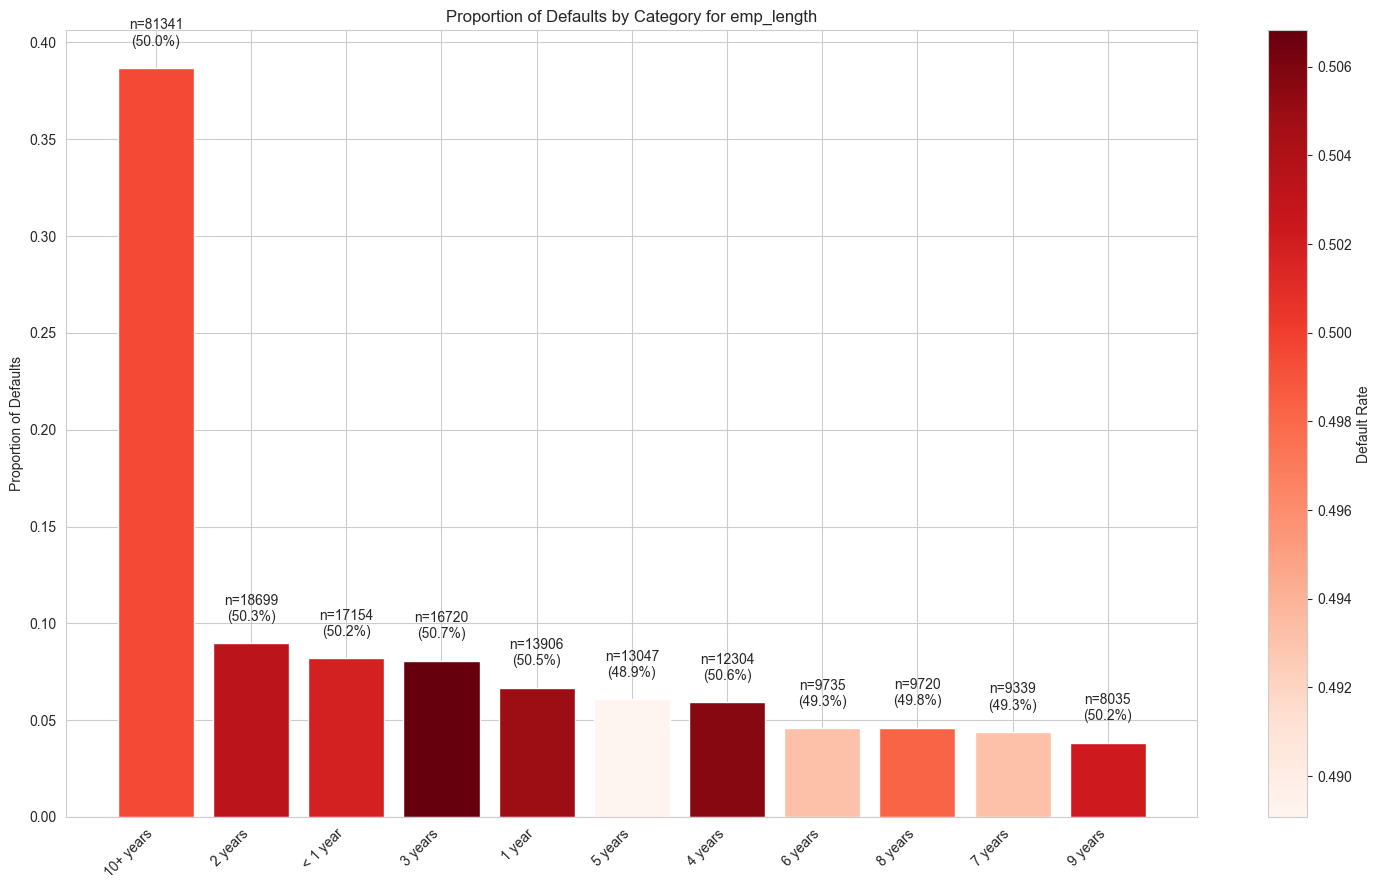


Analyzing home_ownership_RENT:
Number of unique values: 2


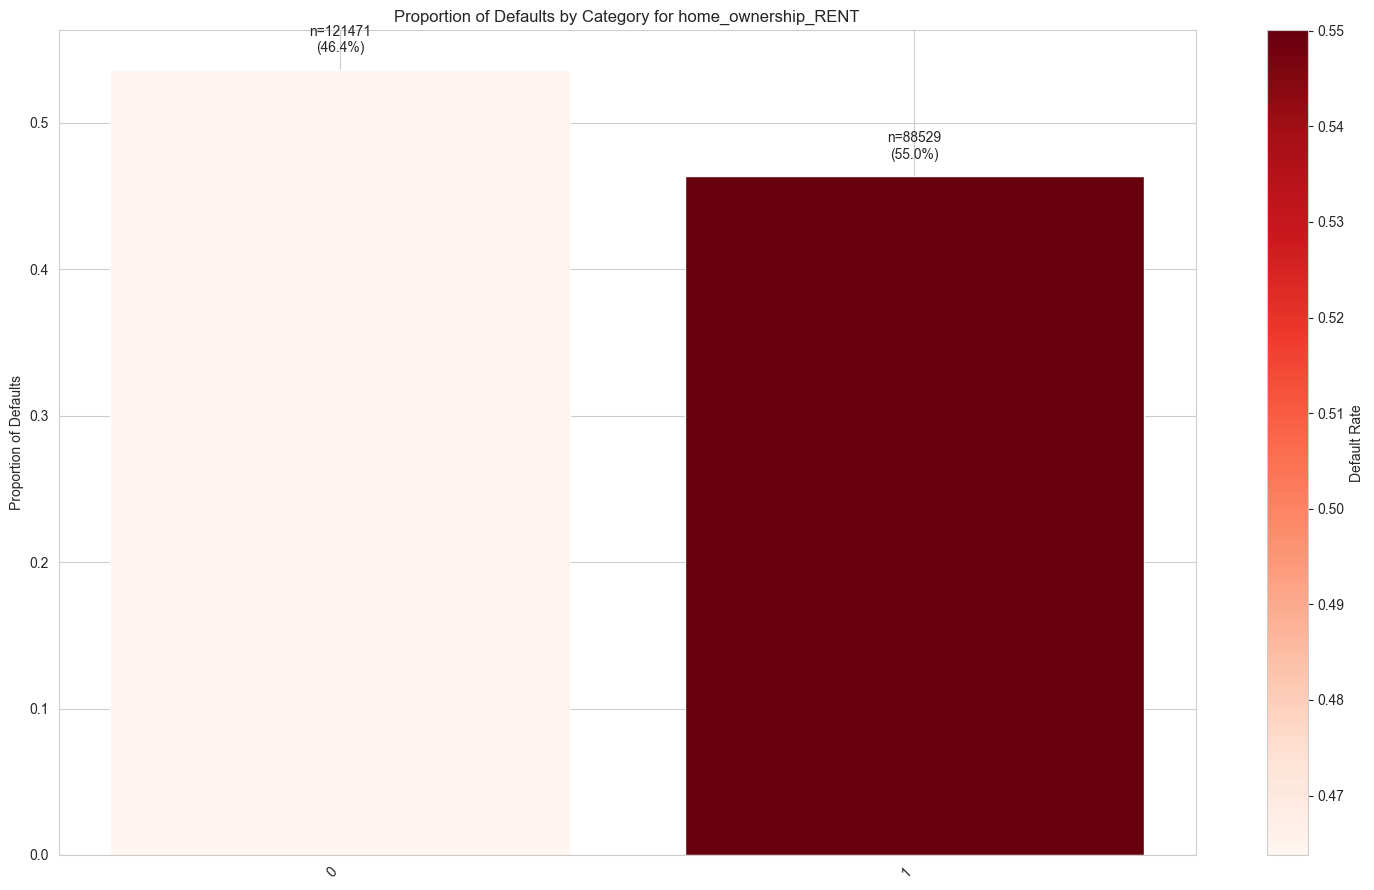


Analyzing home_ownership_MORTGAGE:
Number of unique values: 2


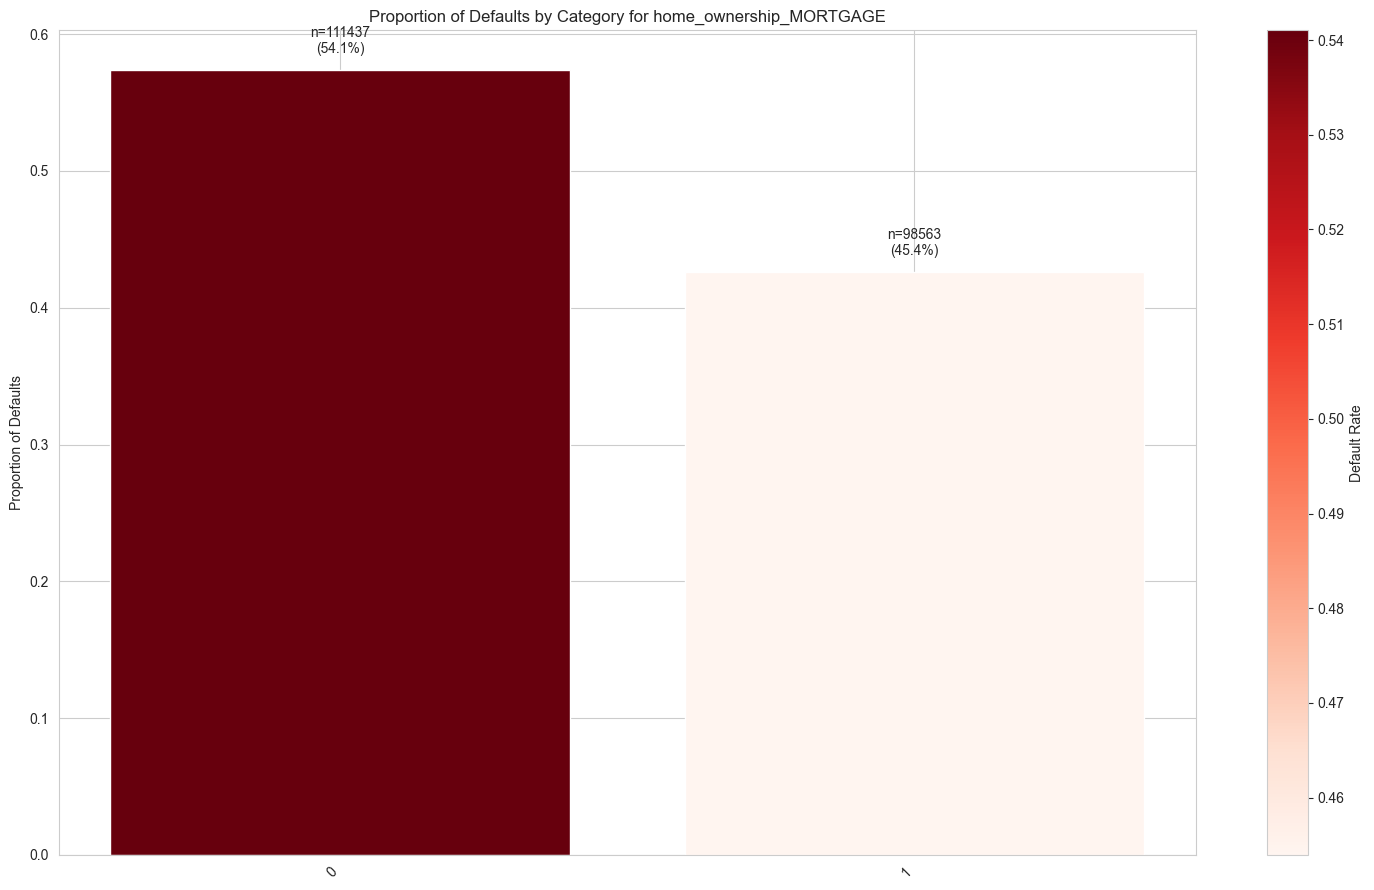


Analyzing home_ownership:
Number of unique values: 6


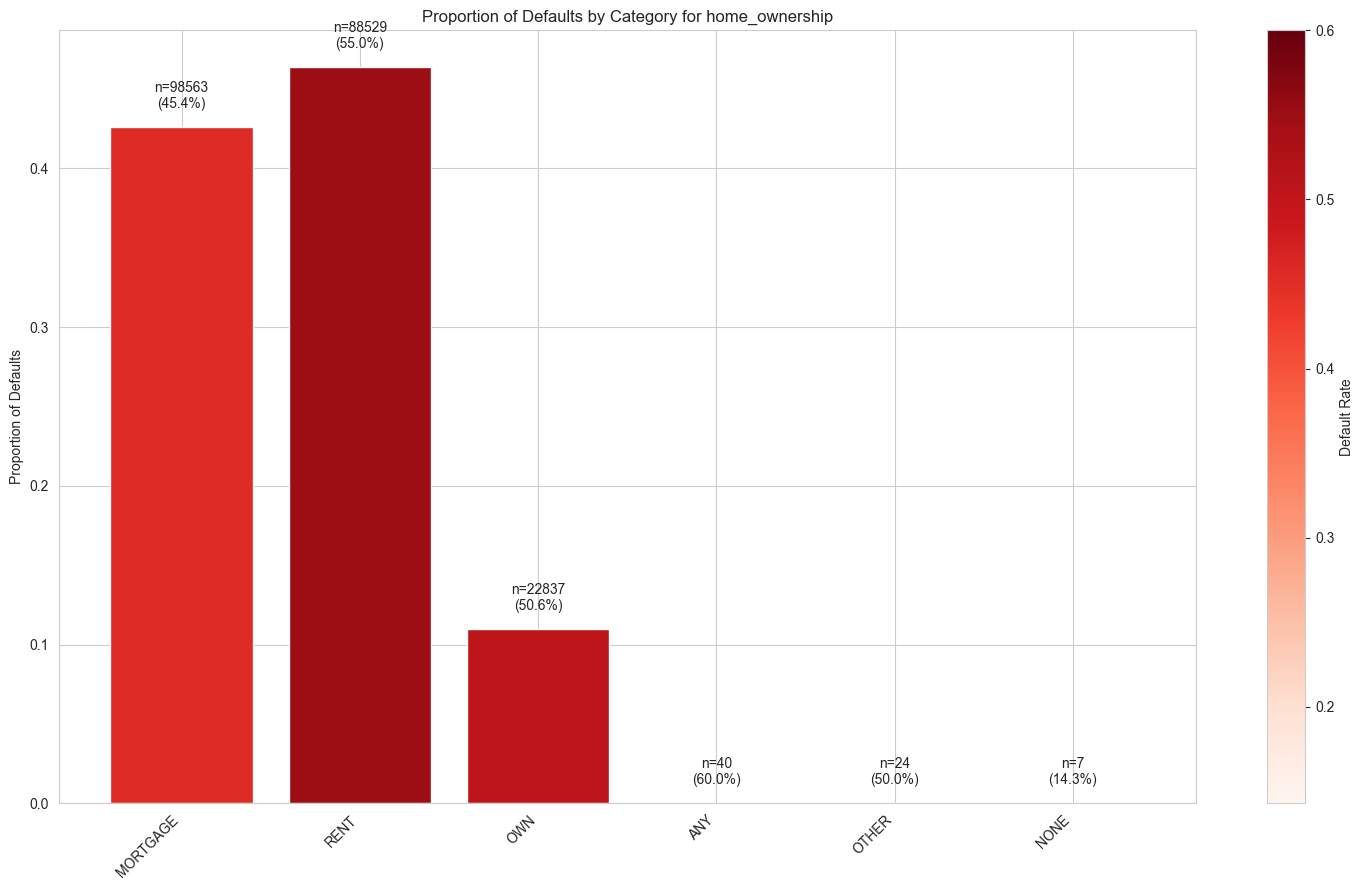


Analyzing inq_last_6mths:
Number of unique values: 9


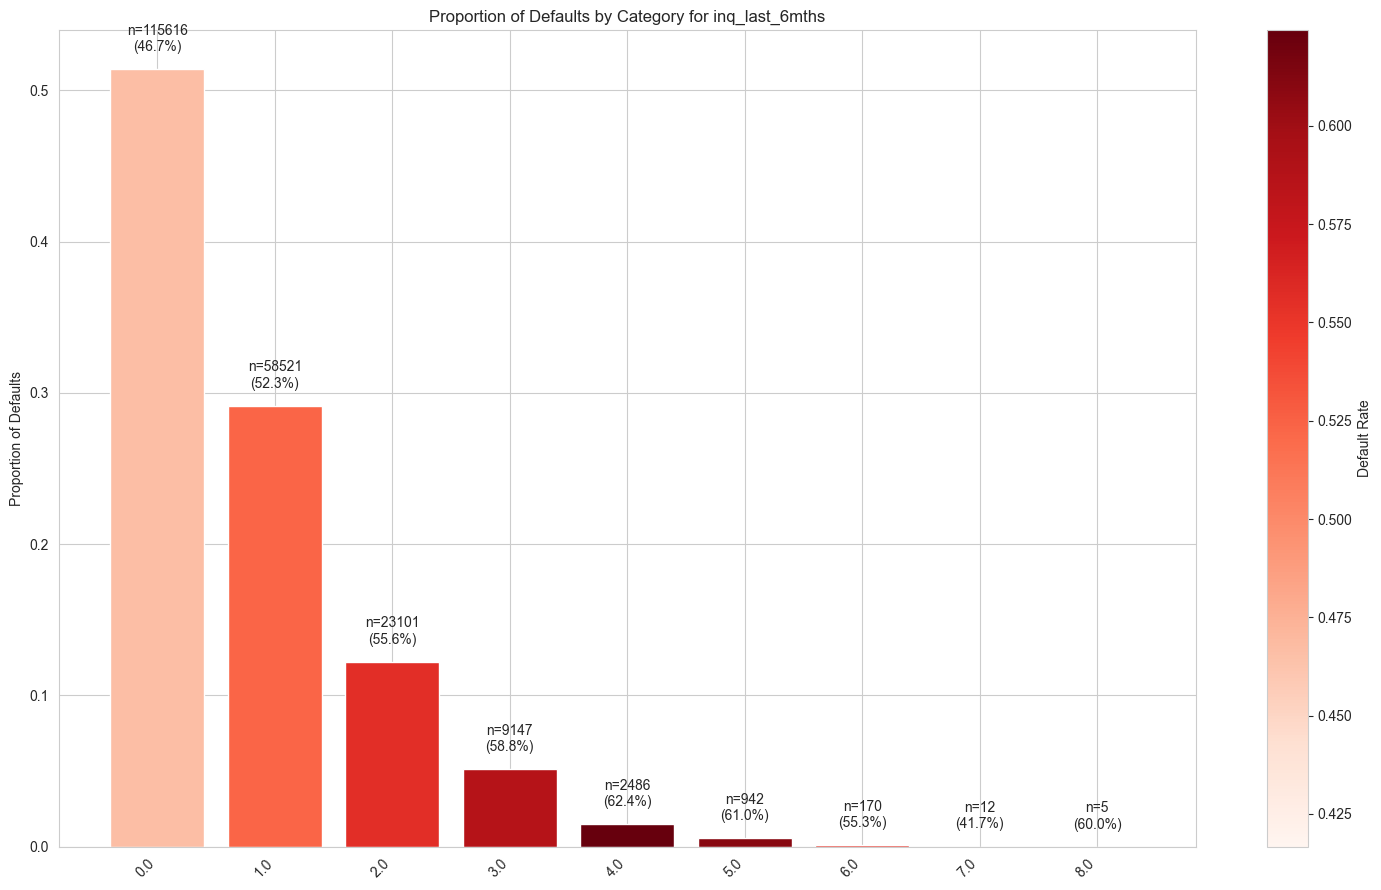


Analyzing pub_rec:
Number of unique values: 25
Too many categories (25). Grouping smaller categories...


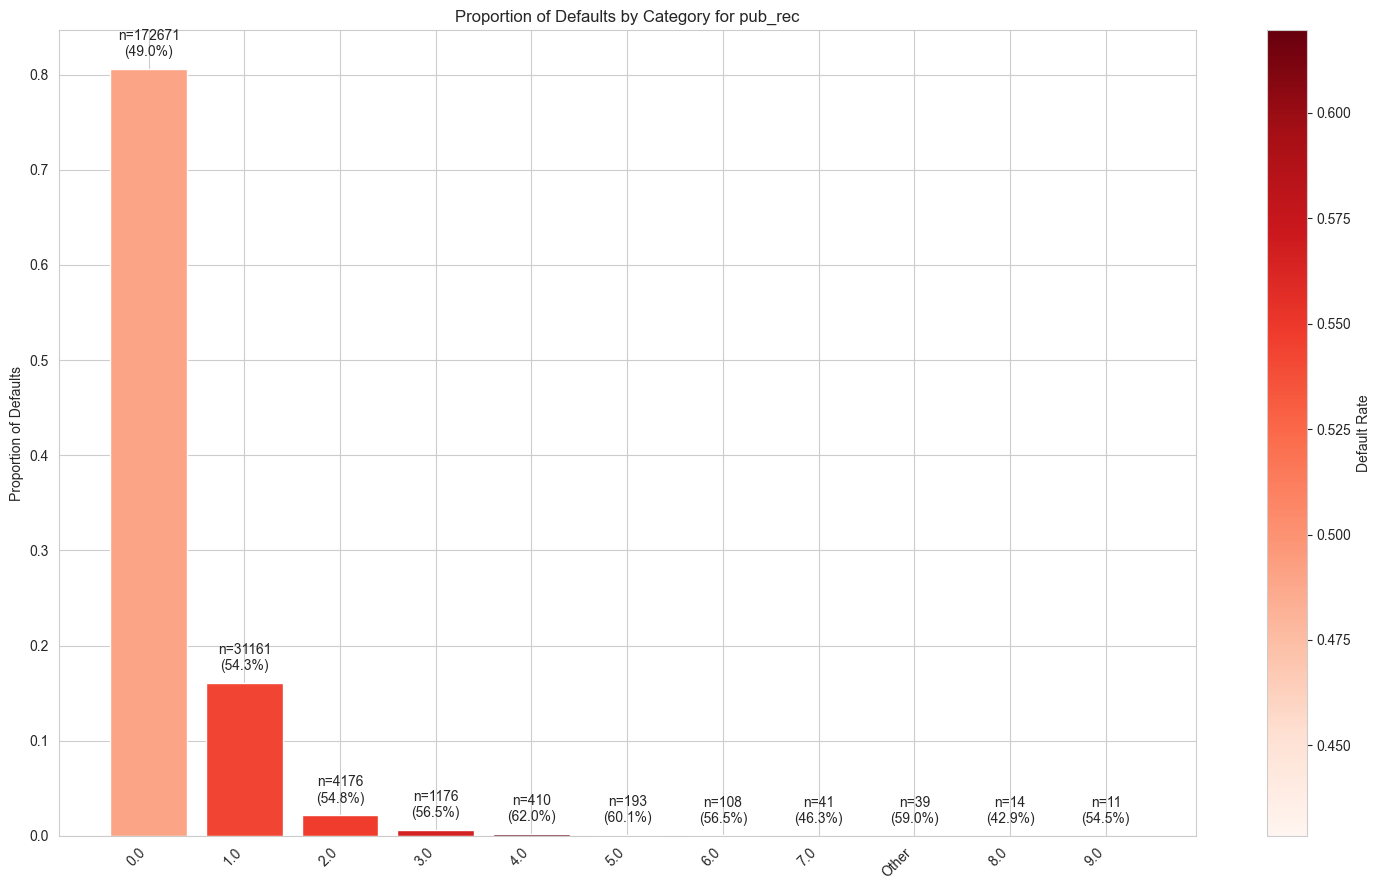


Analyzing pub_rec_bankruptcies:
Number of unique values: 8


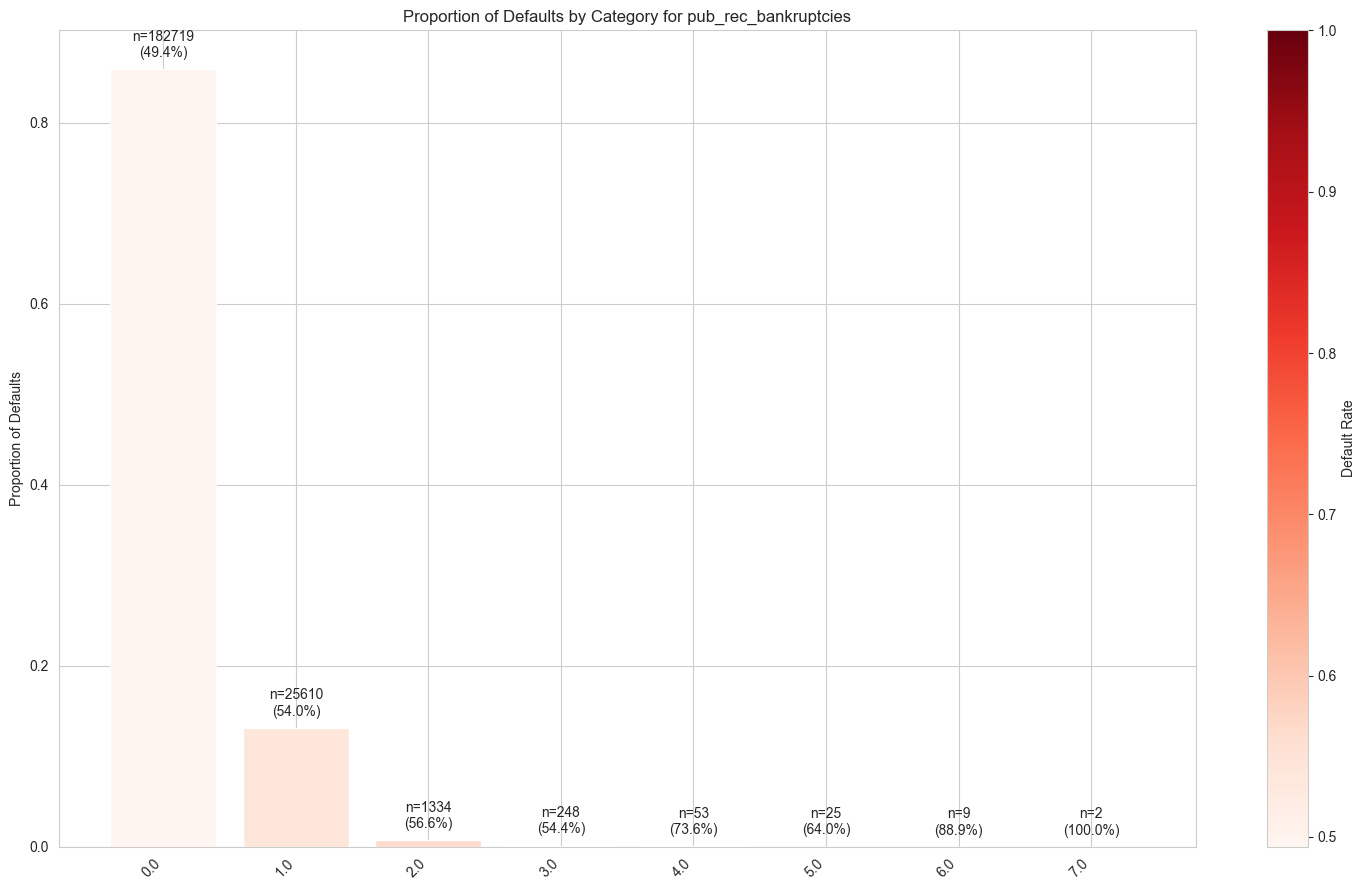


Analyzing delinq_2yrs:
Number of unique values: 24
Too many categories (24). Grouping smaller categories...


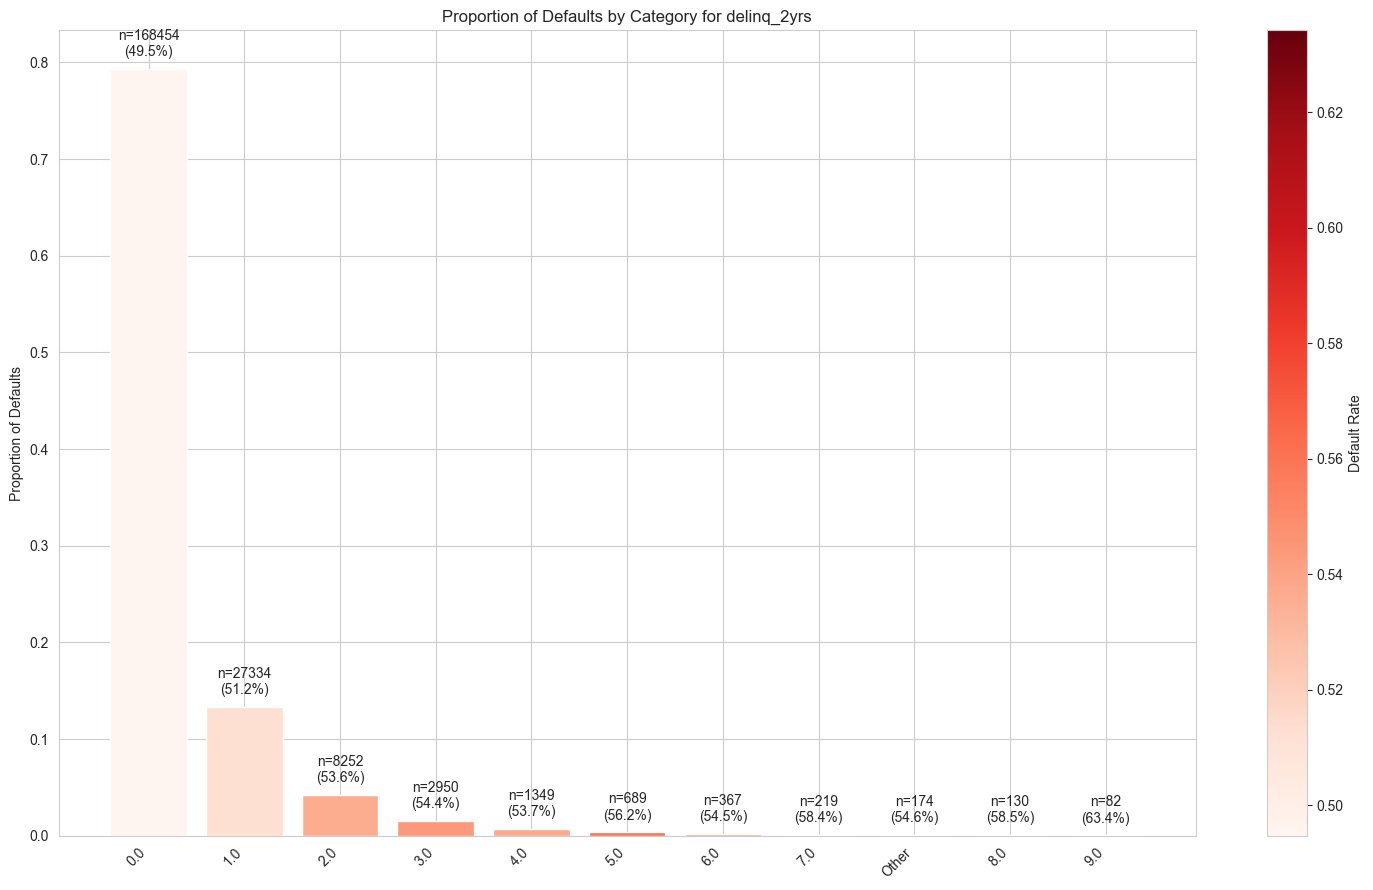


Analyzing term:
Number of unique values: 2


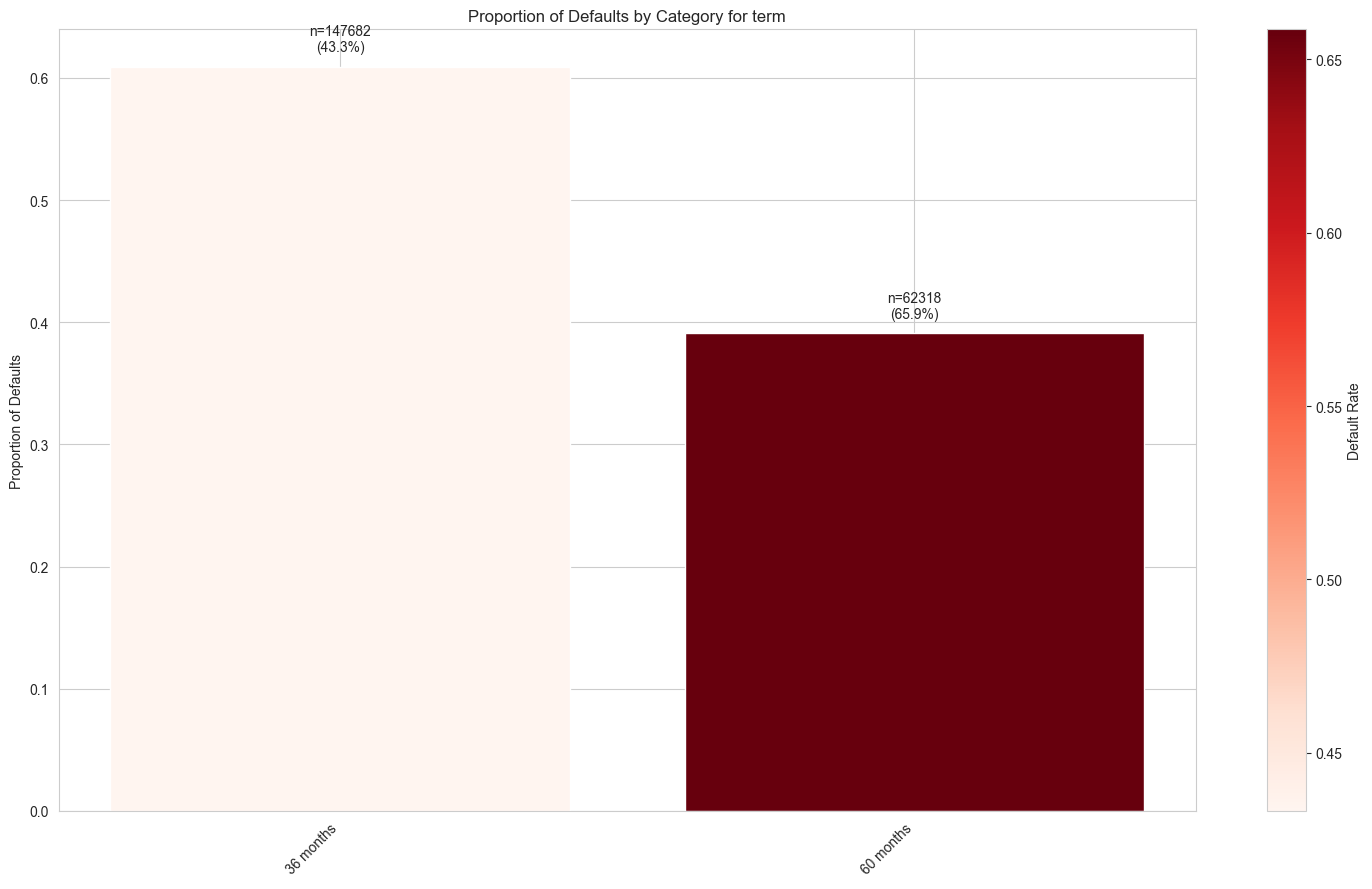


Analyzing purpose:
Number of unique values: 14


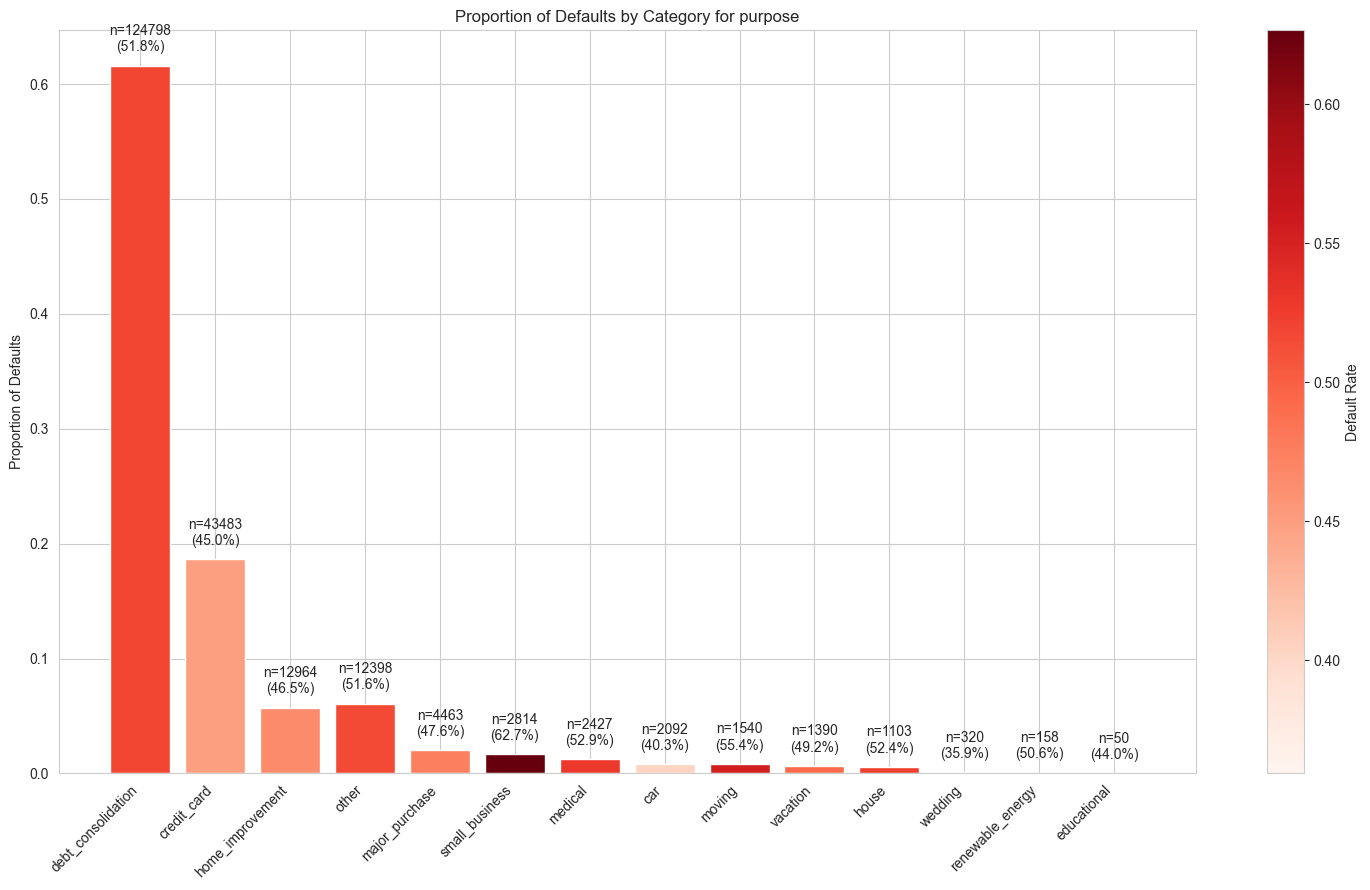


Analyzing has_imputed_values:
Number of unique values: 2


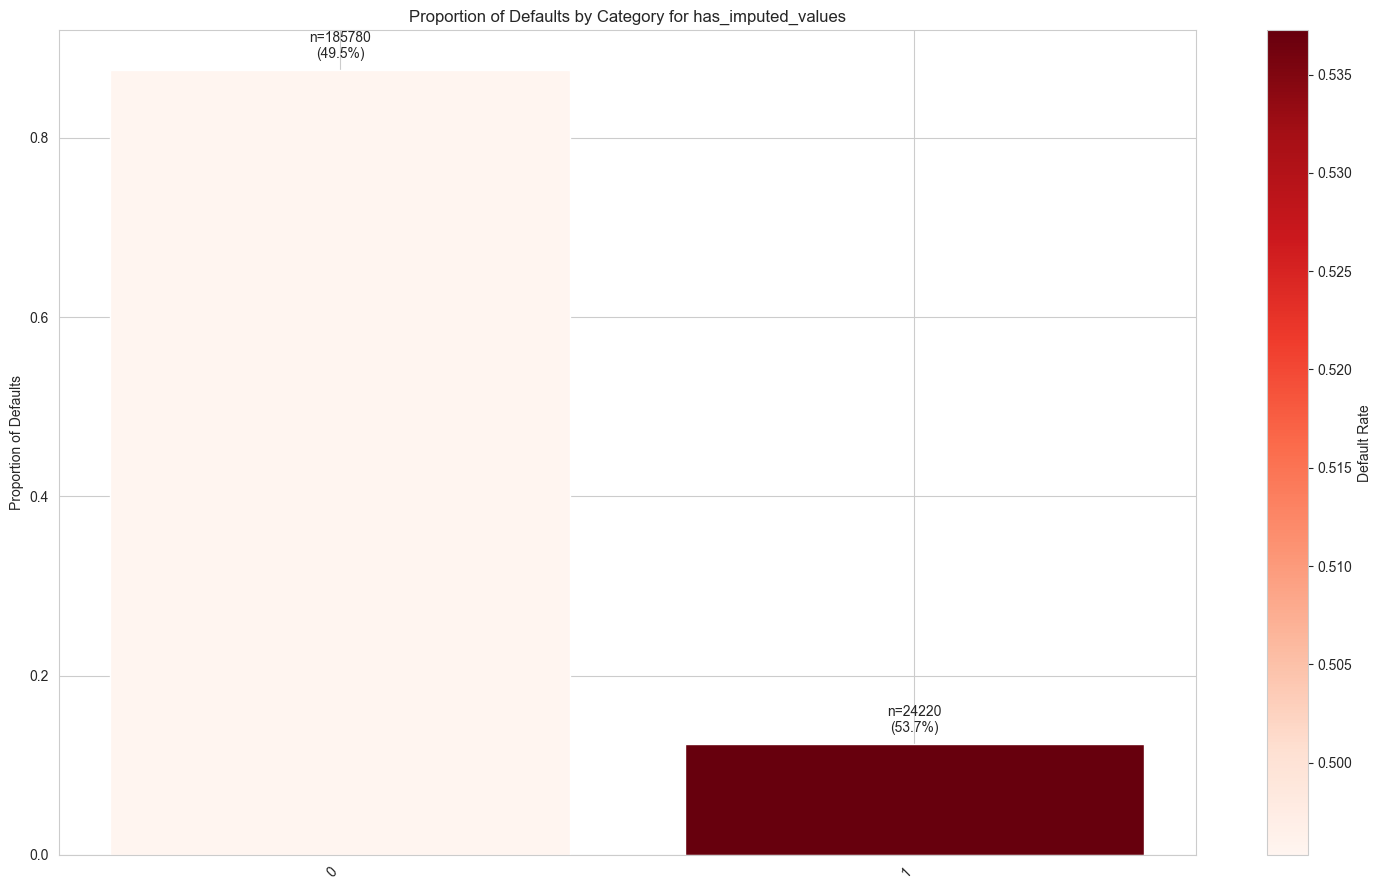

In [161]:
# Analyze categorical variables
print("Analyzing categorical variables...")

# Create a function to analyze categorical variables
def analyze_categorical(df, var, target):
    # Group by the categorical variable
    grouped = df.groupby(var)
    
    # Get total counts for each category
    counts = grouped.size()
    
    # Get default counts (where target = 0)
    default_counts = grouped[target].apply(lambda x: (x == 0).sum())
    
    # Create dataframe with statistics
    cat_stats = pd.DataFrame({
        'count': counts,
        'defaults': default_counts,
    })
    
    # Calculate default rate (percentage of defaults within each category)
    cat_stats['default_rate'] = cat_stats['defaults'] / cat_stats['count']
    
    # Calculate proportion of defaults (percentage of all defaults in this category)
    cat_stats['proportion_of_defaults'] = cat_stats['defaults'] / cat_stats['defaults'].sum()
    
    # Sort by count
    cat_stats = cat_stats.sort_values('count', ascending=False)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 9))
    
    # Create color map based on default rates
    cmap = plt.cm.Reds  # Using Reds to better represent defaults/risk
    norm = plt.Normalize(cat_stats['default_rate'].min(), cat_stats['default_rate'].max())
    
    # Plot bars with colors based on default rate
    bars = ax.bar(range(len(cat_stats)), cat_stats['proportion_of_defaults'], 
                 color=[cmap(norm(rate)) for rate in cat_stats['default_rate']])
    
    # Set x-axis labels
    ax.set_xticks(range(len(cat_stats)))
    ax.set_xticklabels(cat_stats.index, rotation=45, ha='right')
    
    # Set title and labels
    ax.set_title(f"Proportion of Defaults by Category for {var}")
    ax.set_ylabel("Proportion of Defaults")
    
    # Add count and default rate labels
    for i, bar in enumerate(bars):
        category_count = cat_stats['count'].iloc[i]
        default_rate = cat_stats['default_rate'].iloc[i]
        ax.annotate(f"n={category_count}\n({default_rate:.1%})", 
                   (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01), 
                   ha='center', va='bottom')
    
    # Add a colorbar to show the default rate scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Default Rate')
    
    plt.tight_layout()
    plt.show()
    
    return cat_stats

# Process each categorical variable
for var in categorical_vars:
    print(f"\nAnalyzing {var}:")
    
    # Check number of unique values
    n_unique = df[var].nunique()
    print(f"Number of unique values: {n_unique}")
    
    # If too many unique values, take top categories
    if n_unique > 15:
        print(f"Too many categories ({n_unique}). Grouping smaller categories...")
        top_categories = df[var].value_counts().nlargest(10).index
        df_temp = df.copy()
        df_temp[var] = df_temp[var].apply(lambda x: x if x in top_categories else 'Other')
        cat_stats = analyze_categorical(df_temp, var, target_var)
    else:
        cat_stats = analyze_categorical(df, var, target_var)
    
    analysis_results['categorical_stats'][var] = cat_stats


Analyzing emp_length:
Number of unique values: 11


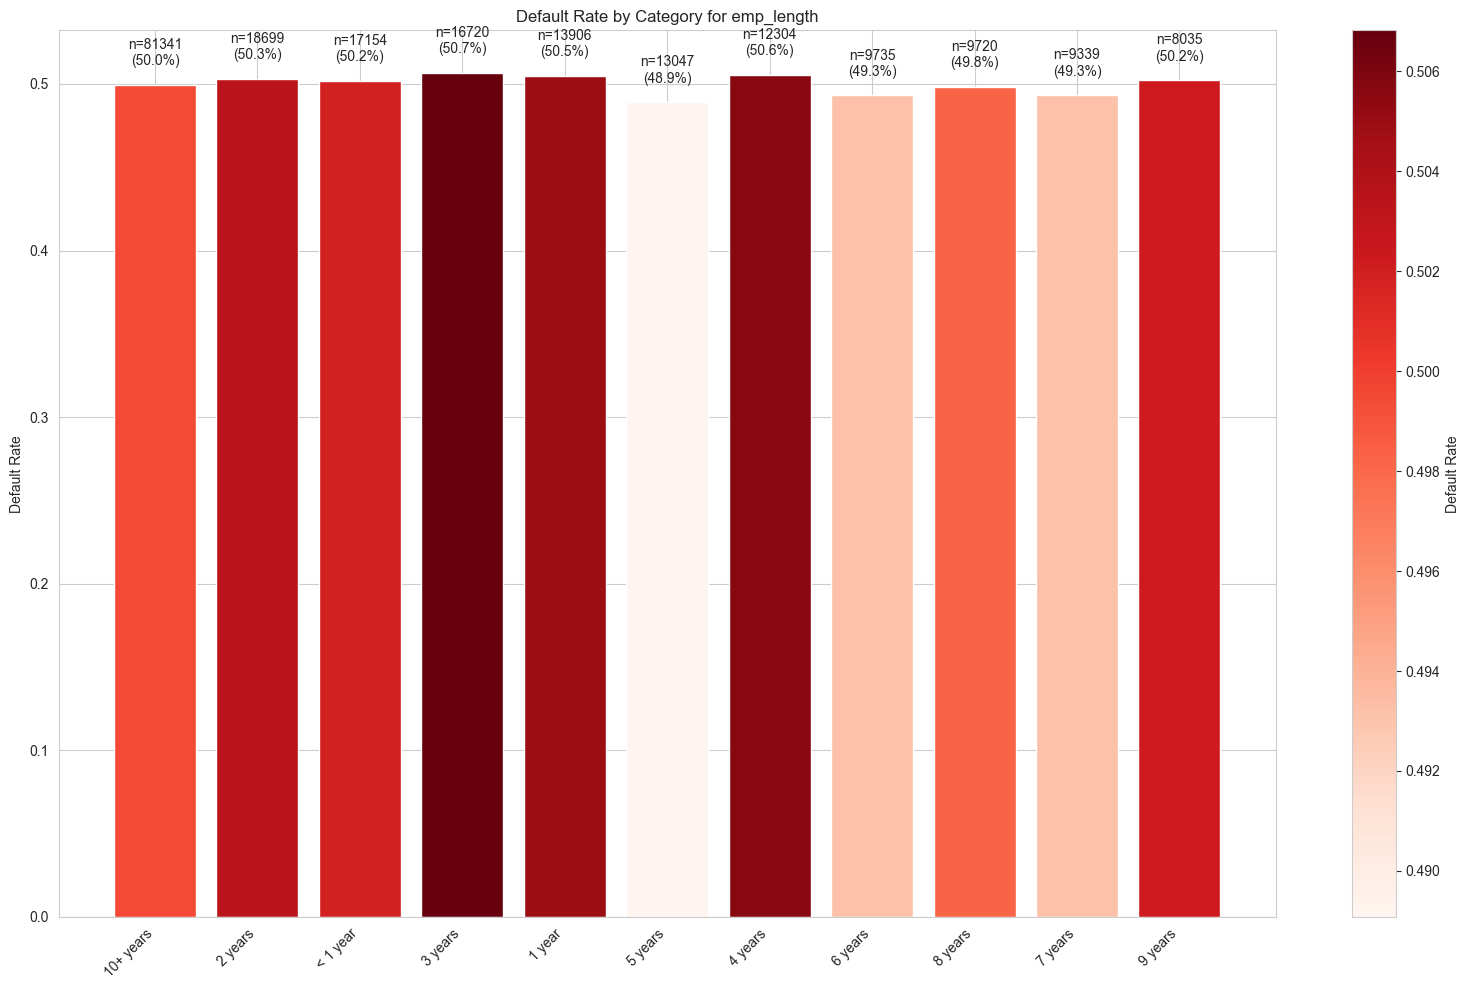


Analyzing home_ownership_RENT:
Number of unique values: 2


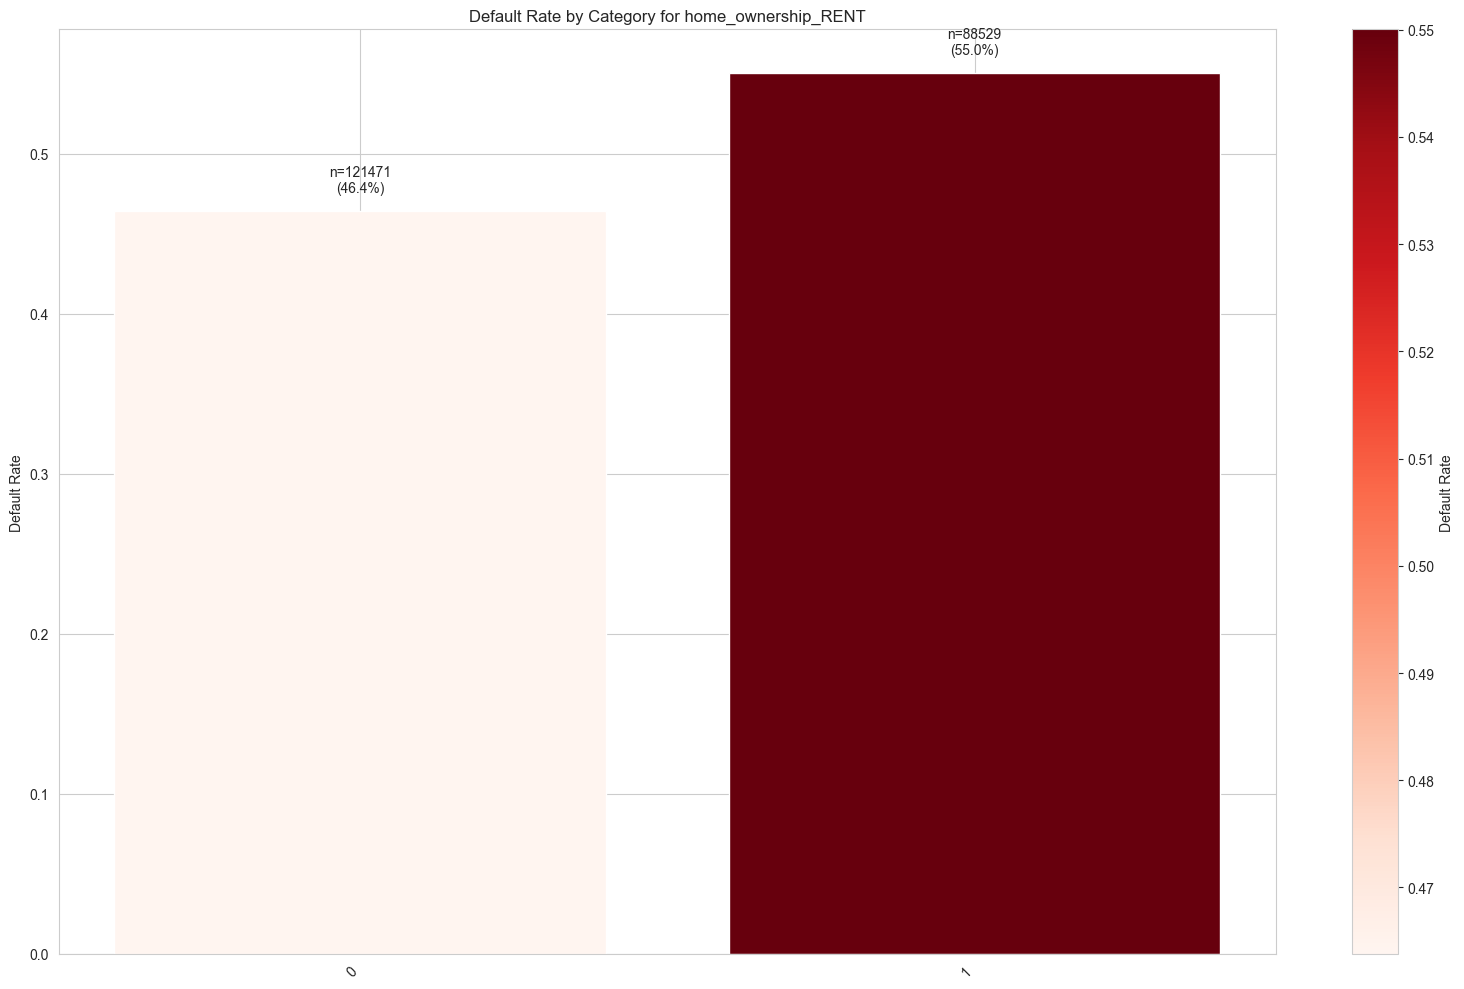


Analyzing home_ownership_MORTGAGE:
Number of unique values: 2


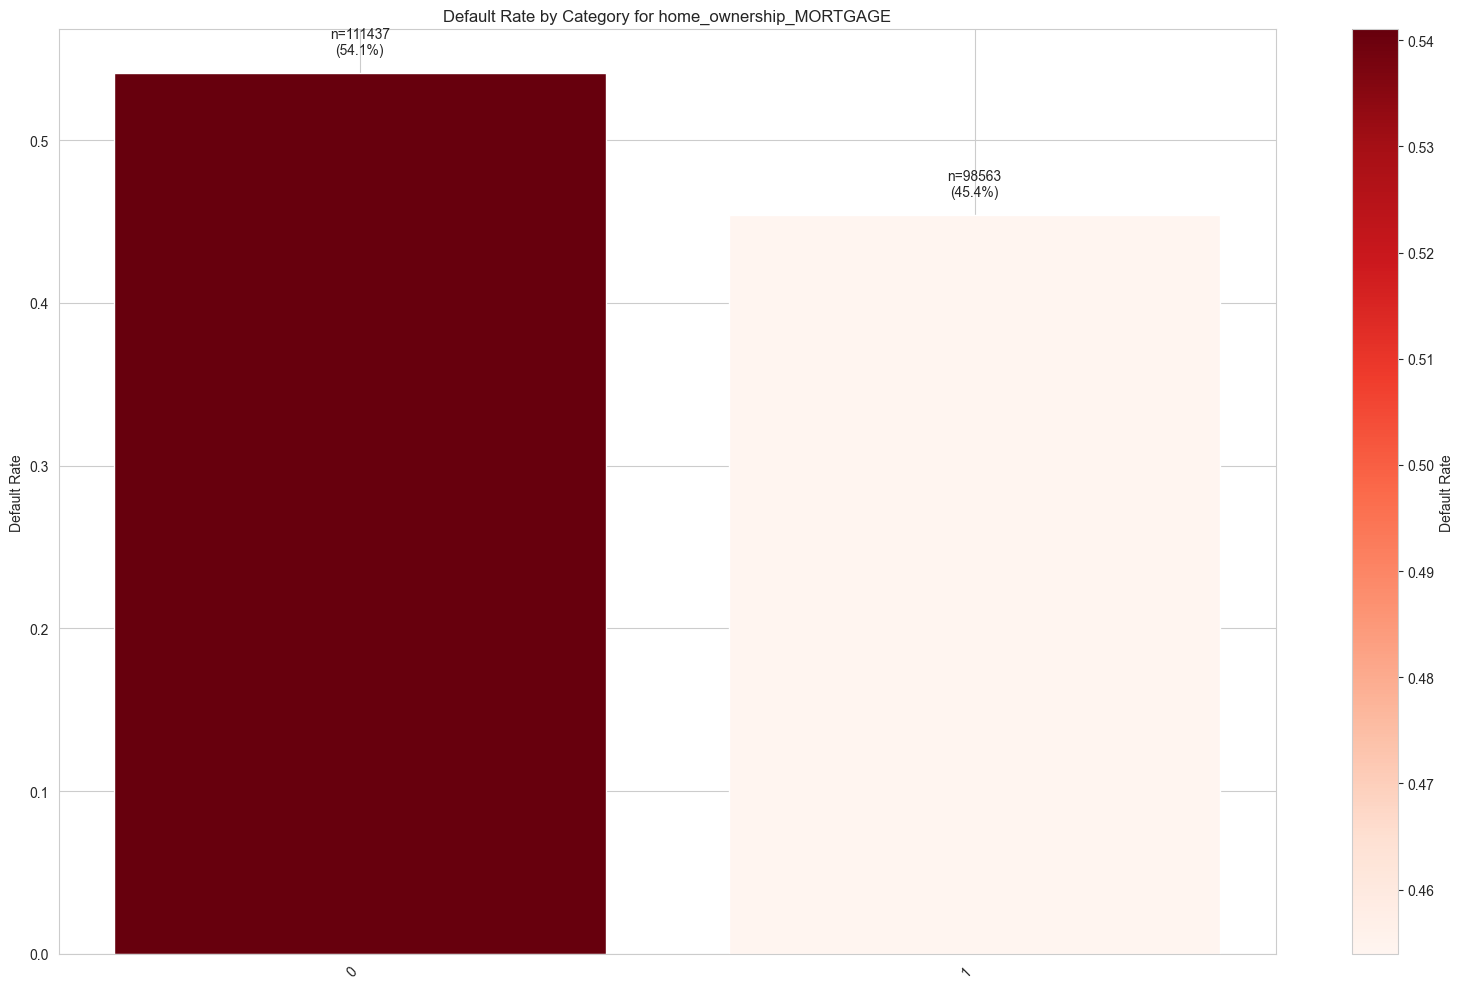


Analyzing home_ownership:
Number of unique values: 6
Grouped 3 categories with fewer than 200 observations into 'Other (Small Categories)'


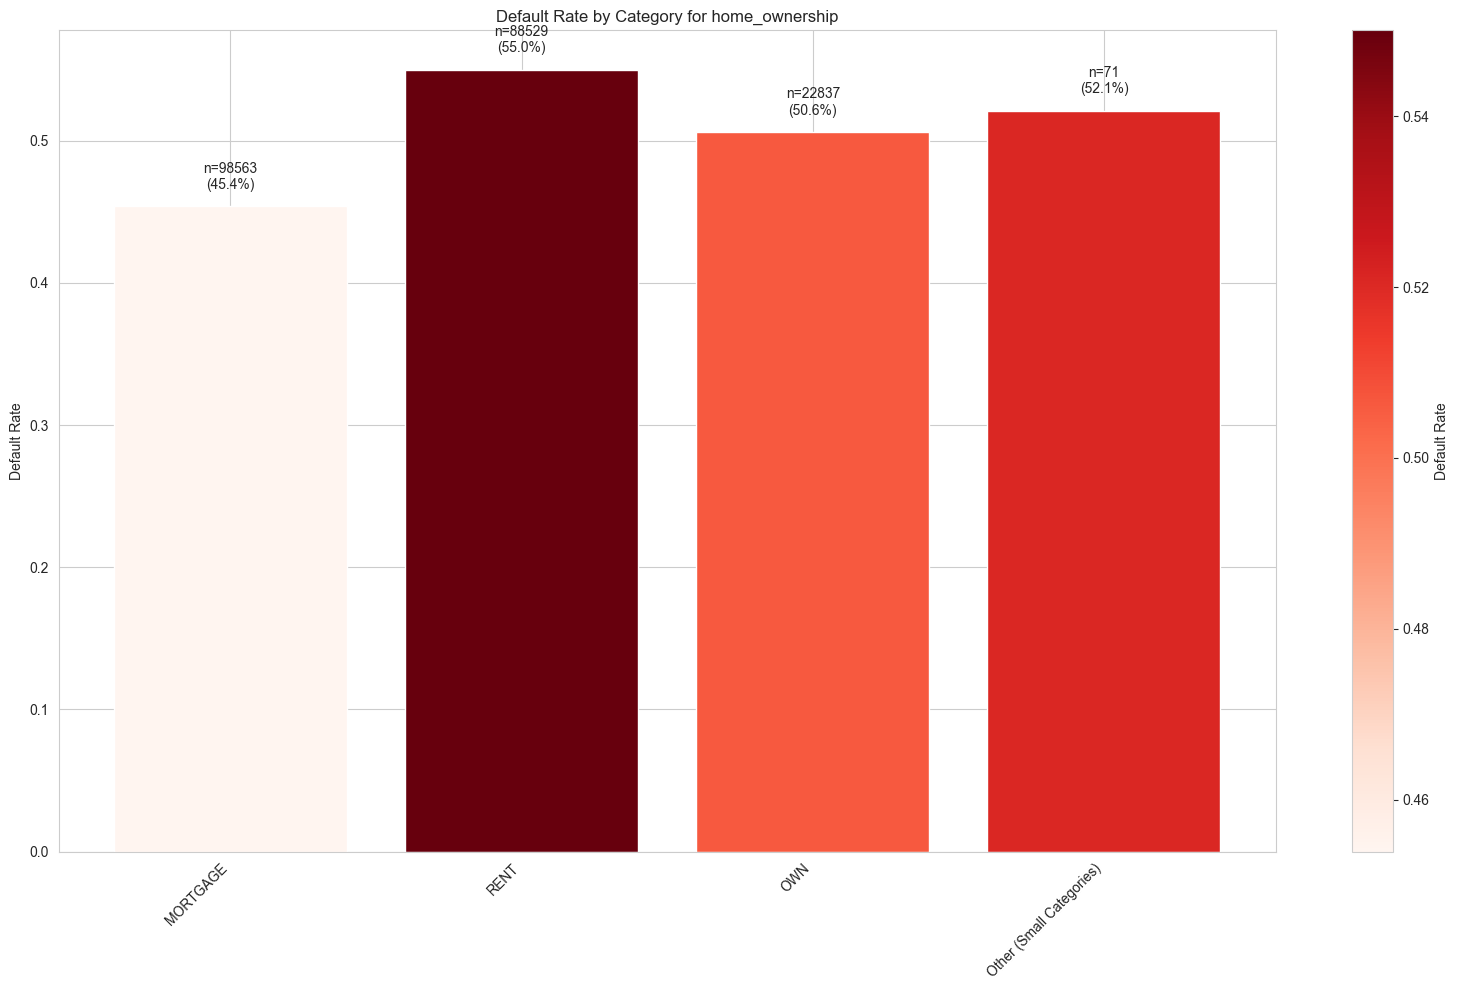


Analyzing inq_last_6mths:
Number of unique values: 9
Grouped 3 categories with fewer than 200 observations into 'Other (Small Categories)'


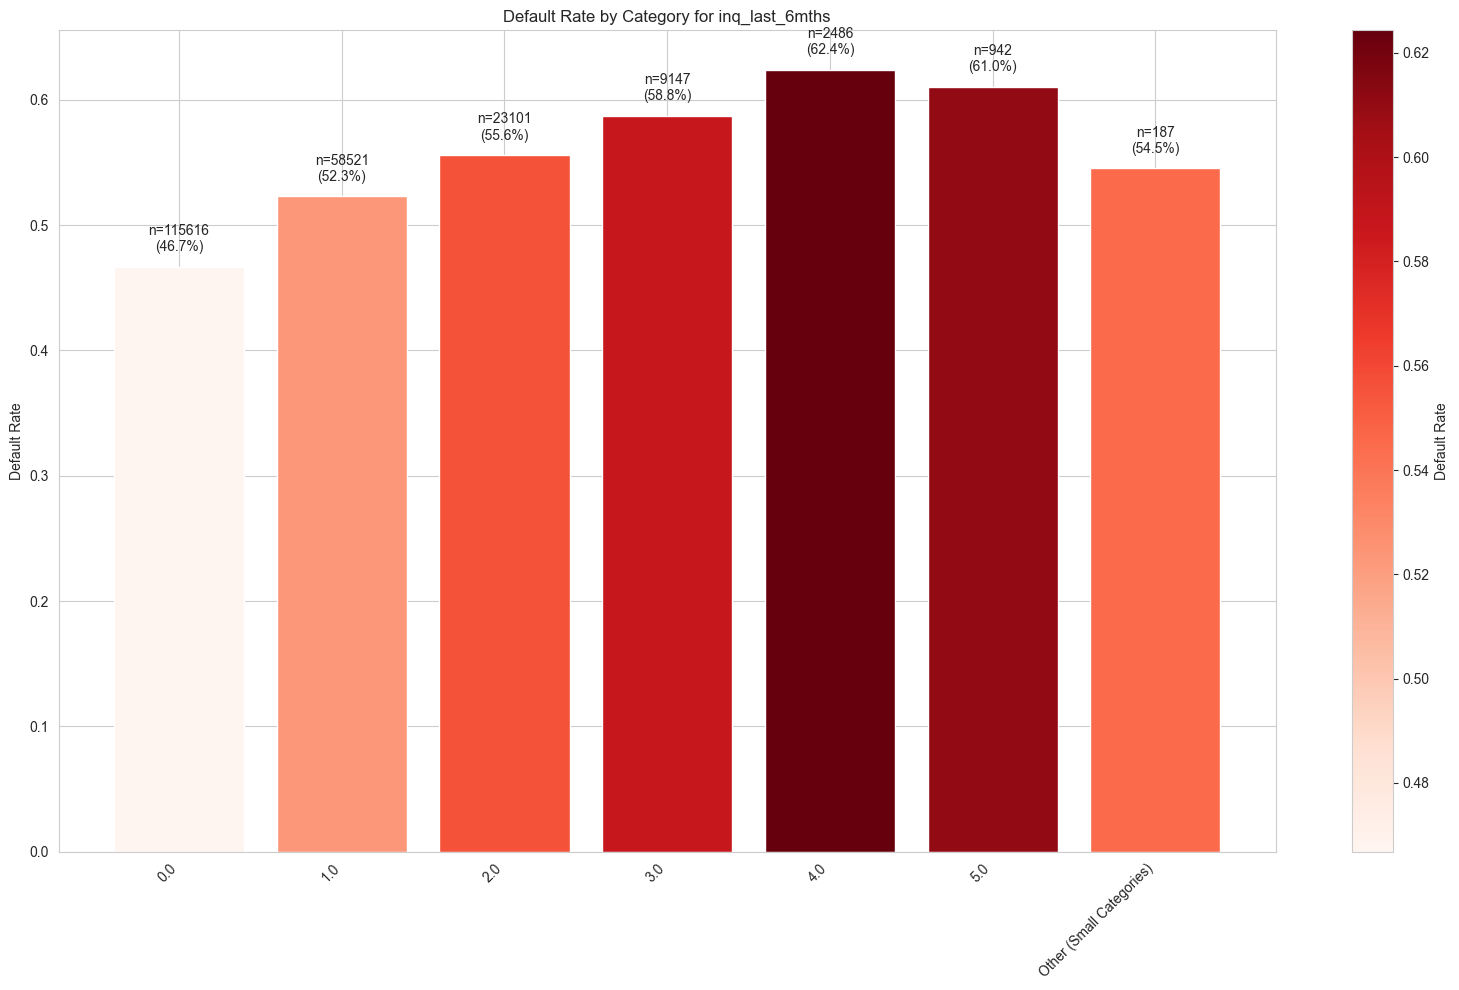


Analyzing pub_rec:
Number of unique values: 25
Too many categories (25). Showing only top categories...
Grouped 6 categories with fewer than 200 observations into 'Other (Small Categories)'


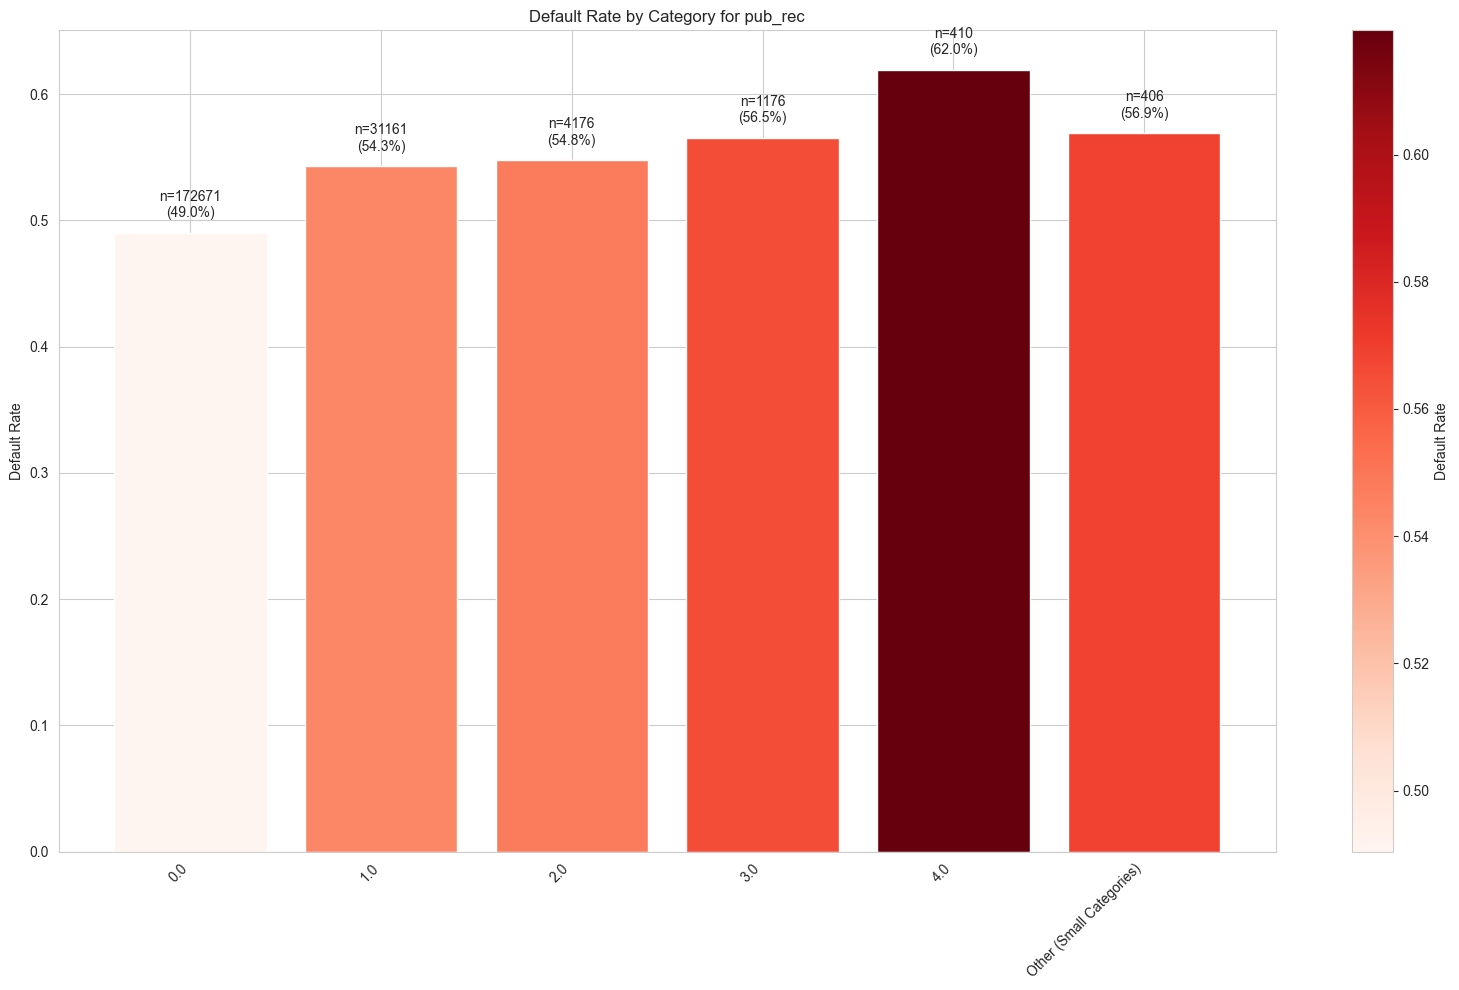


Analyzing pub_rec_bankruptcies:
Number of unique values: 8
Grouped 4 categories with fewer than 200 observations into 'Other (Small Categories)'


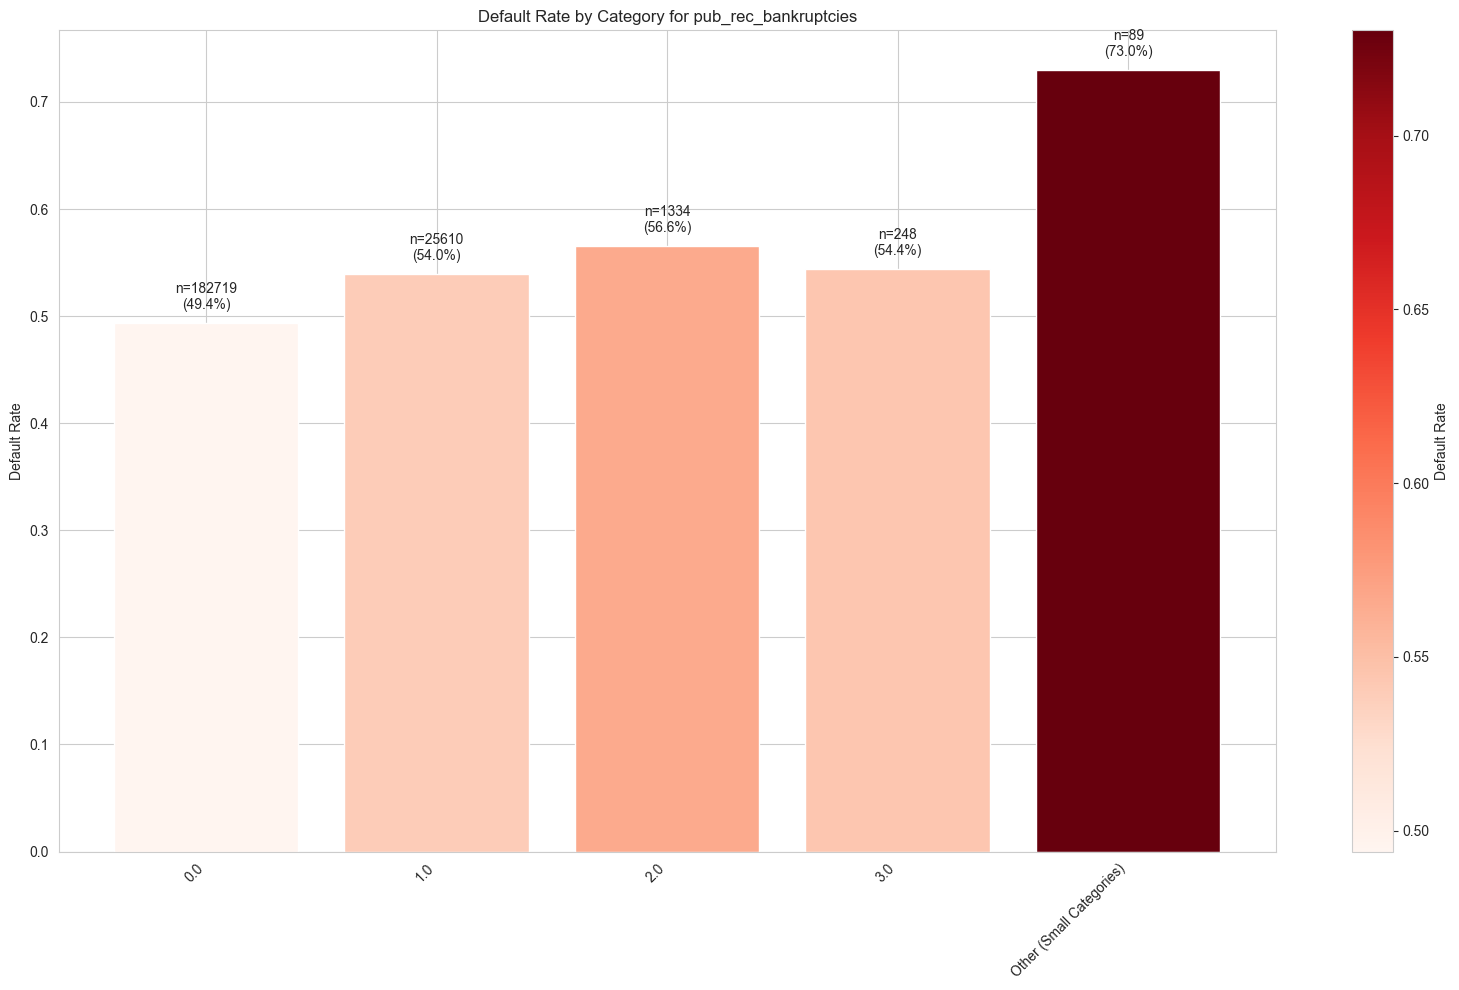


Analyzing delinq_2yrs:
Number of unique values: 24
Too many categories (24). Showing only top categories...
Grouped 3 categories with fewer than 200 observations into 'Other (Small Categories)'


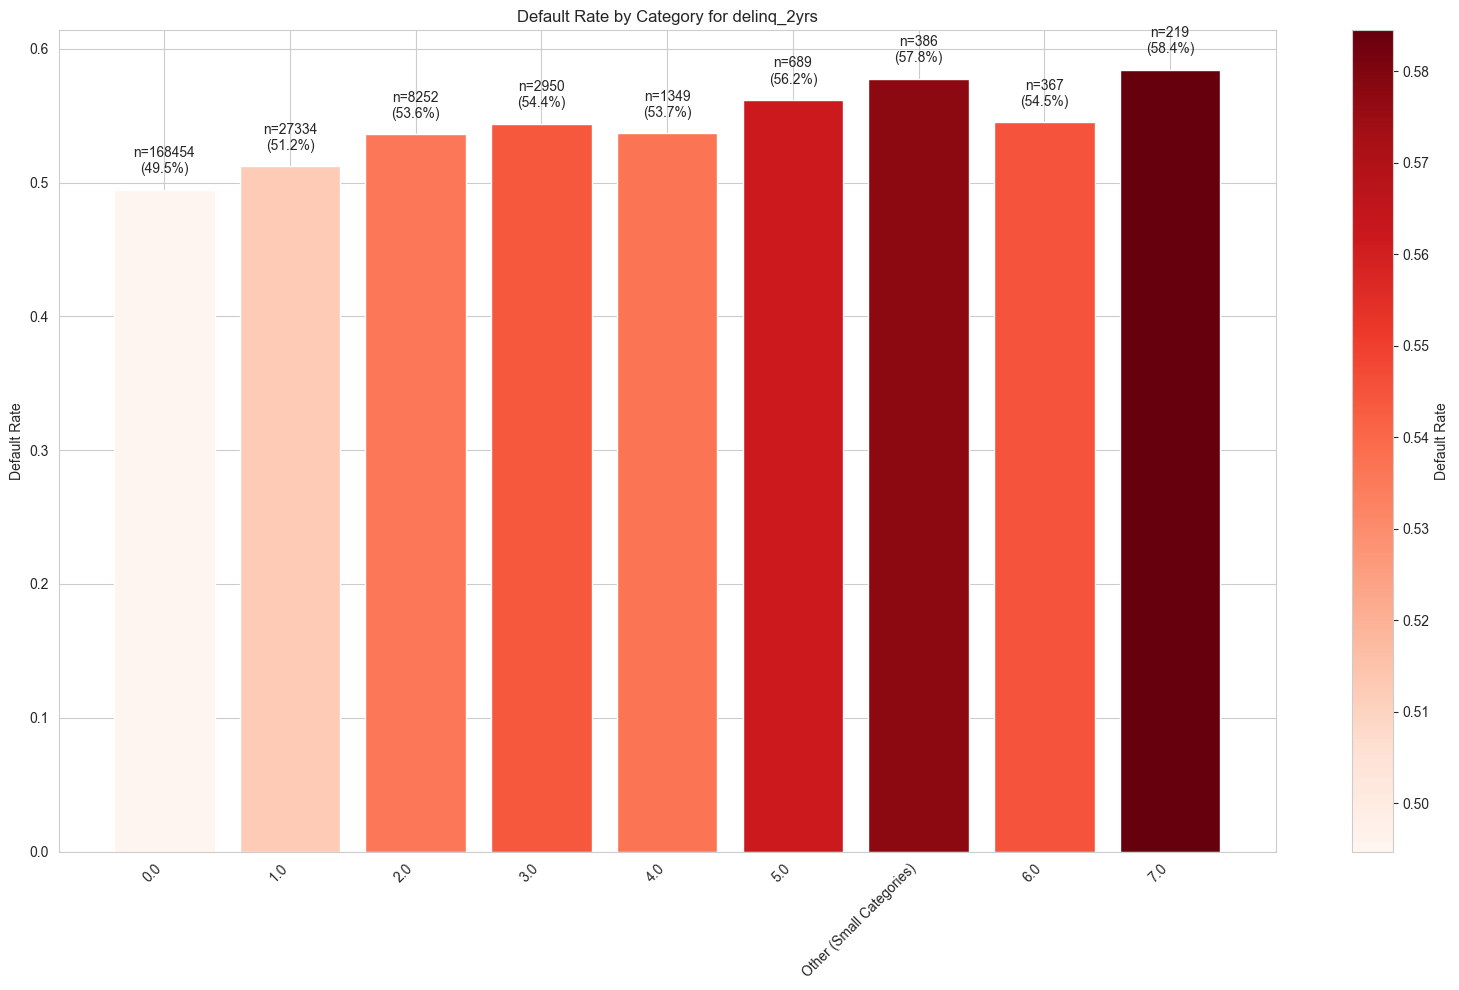


Analyzing term:
Number of unique values: 2


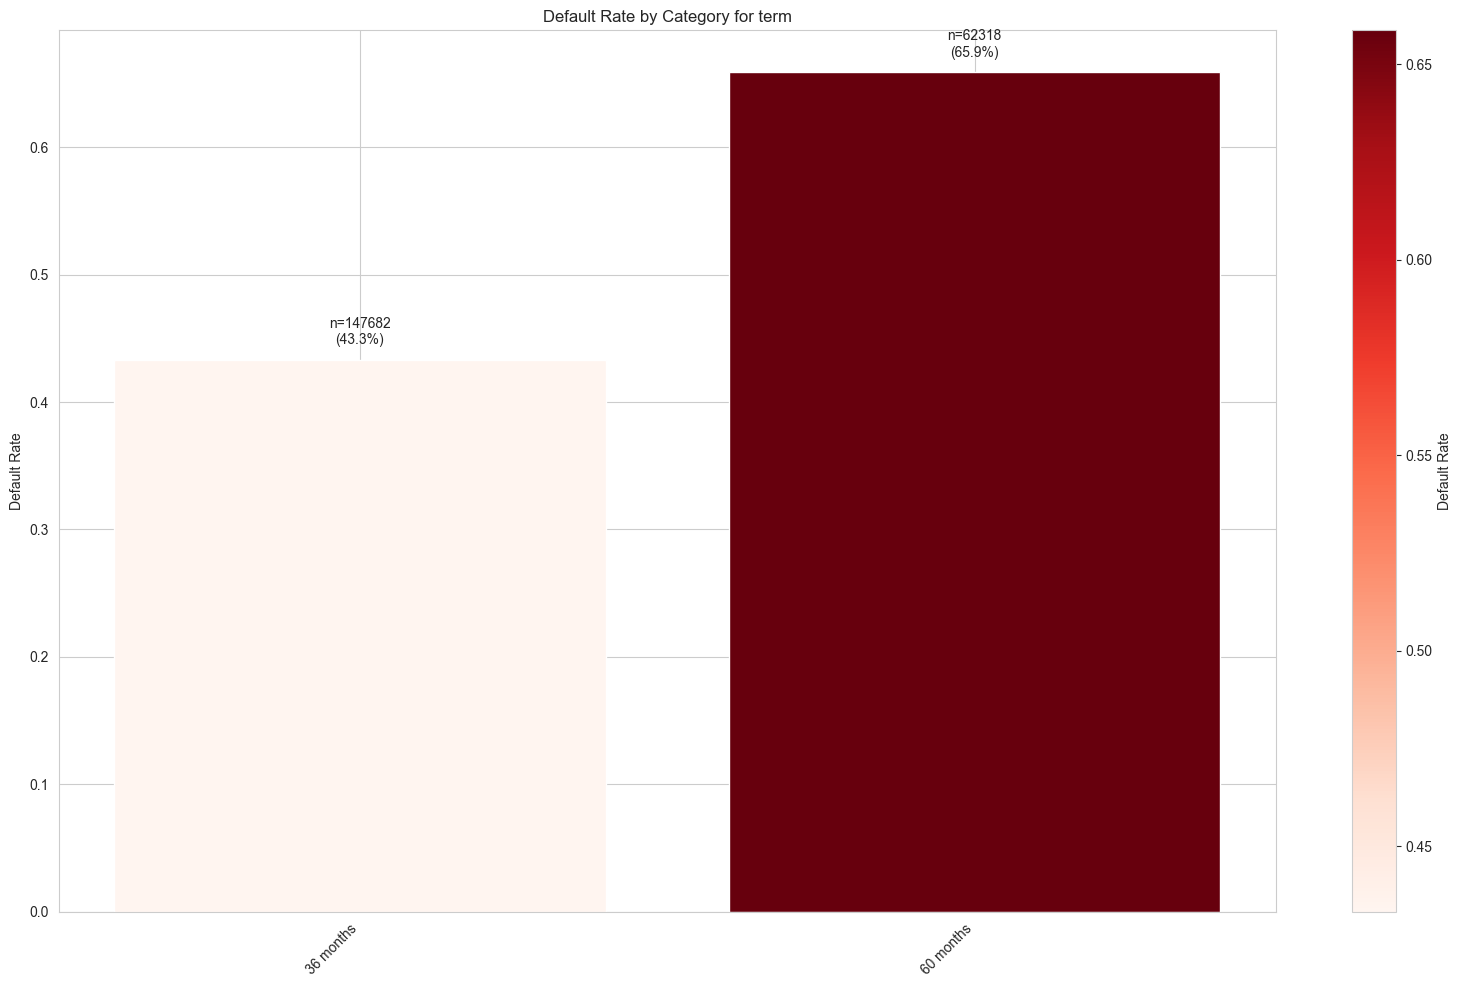


Analyzing purpose:
Number of unique values: 14
Grouped 2 categories with fewer than 200 observations into 'Other (Small Categories)'


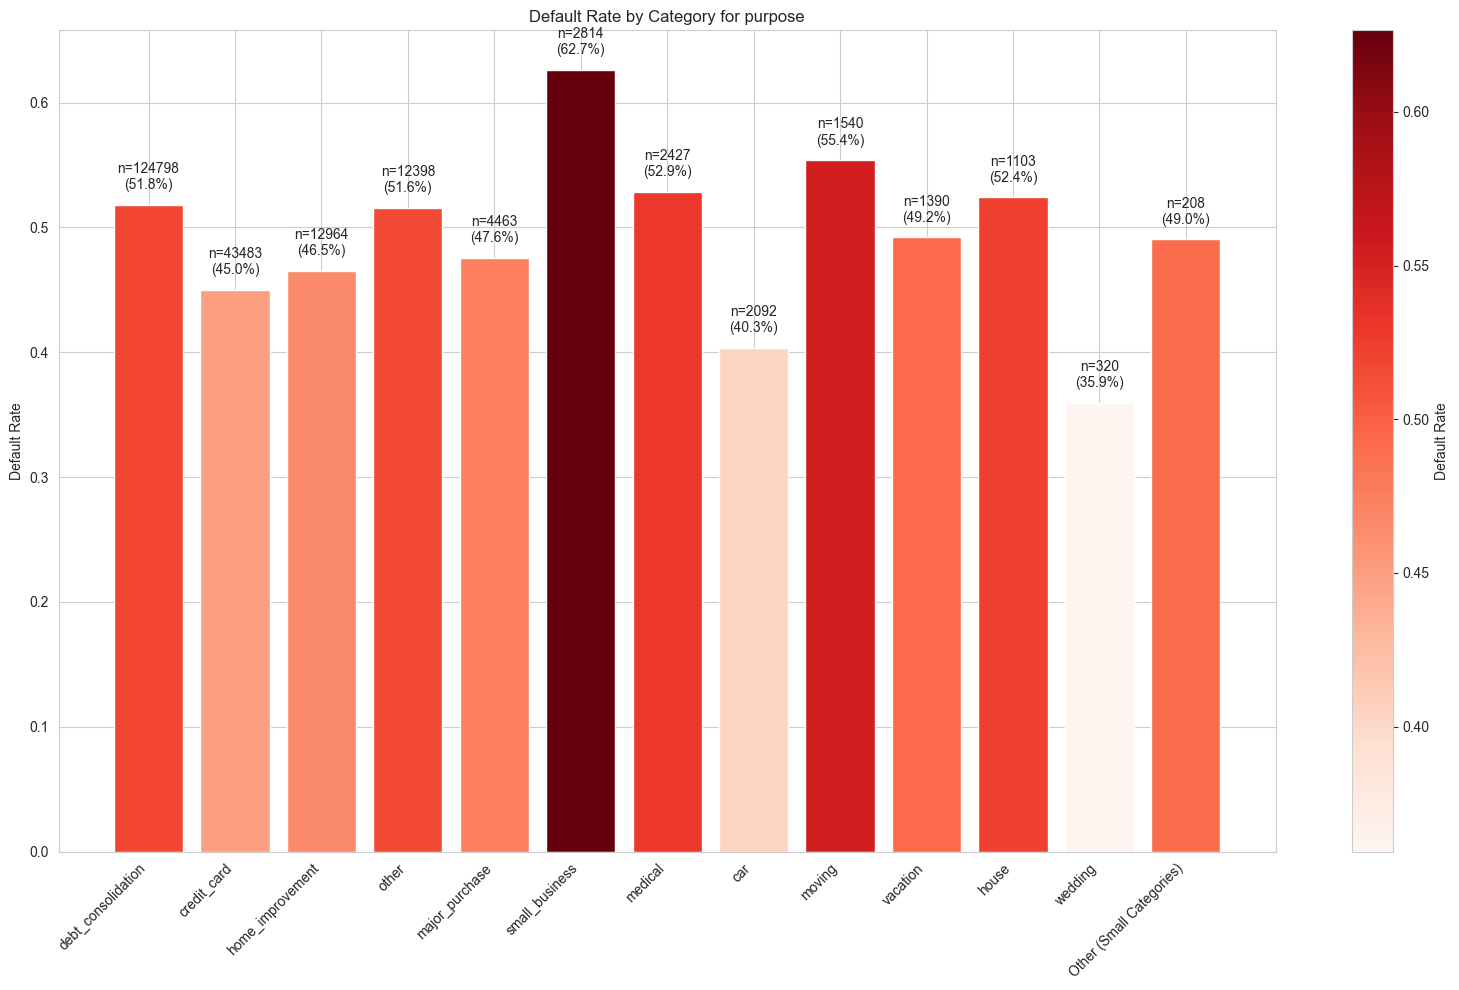


Analyzing has_imputed_values:
Number of unique values: 2


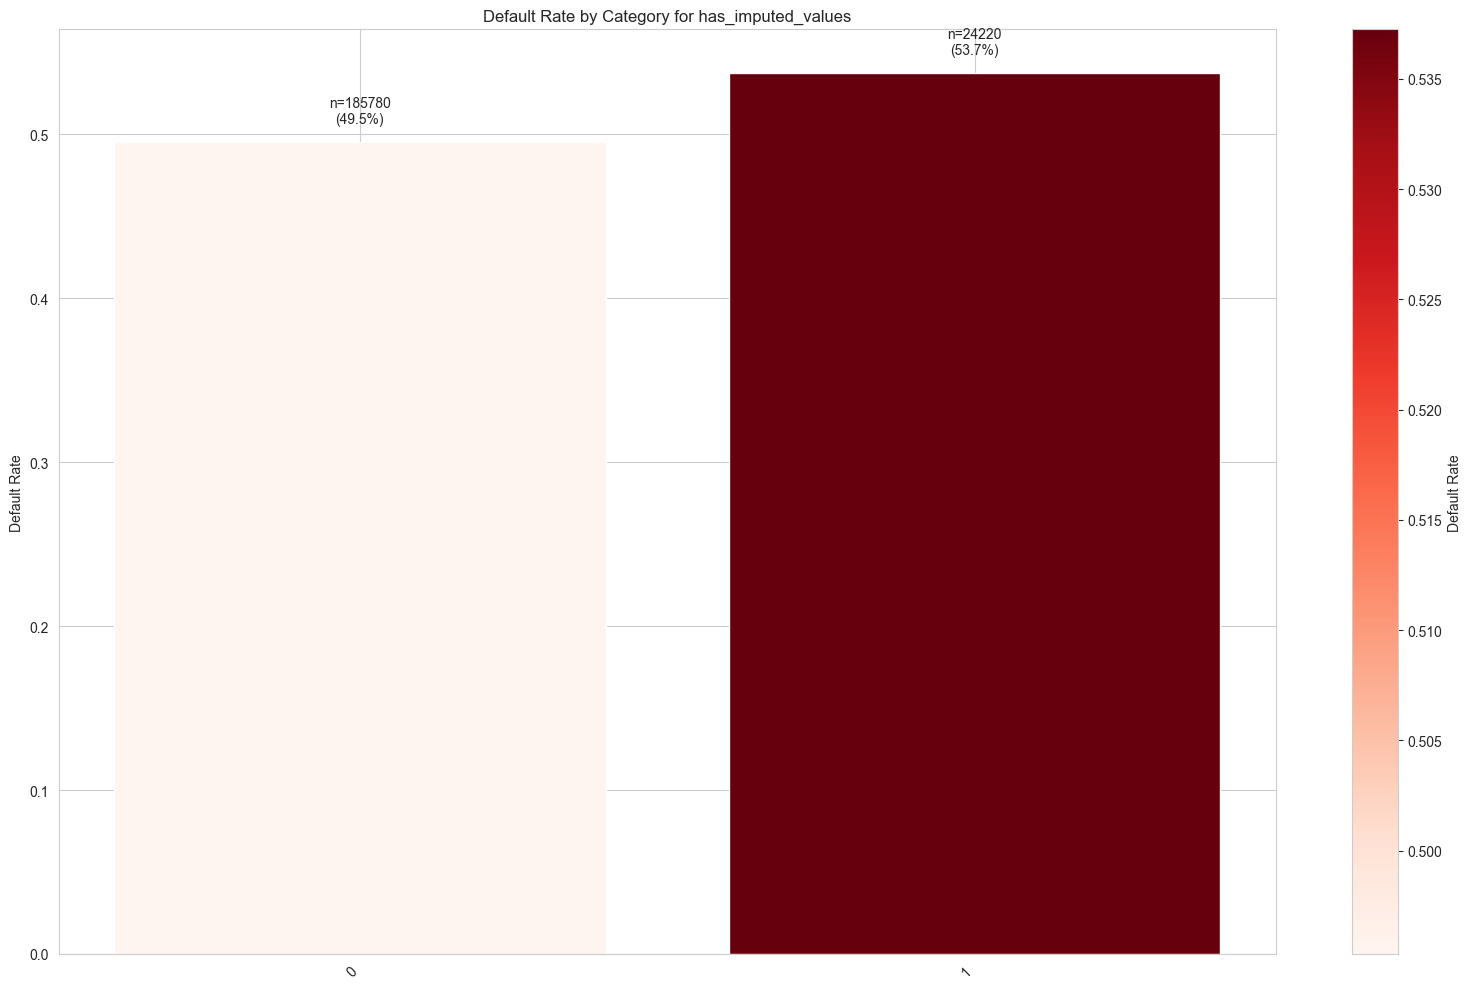

In [162]:
# Process each categorical variable
def analyze_categorical(df, var, target, min_obs=200):
    """
    Analyze categorical variables and their relationship with a target variable.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset containing the variables
    var : str
        The categorical variable to analyze
    target : str
        The target variable (binary, where 0 typically represents default)
    min_obs : int, default=200
        Minimum observations required for a category to remain separate
        
    Returns:
    --------
    pandas.DataFrame
        Statistics about each category
    """
    # First, consolidate small categories
    value_counts = df[var].value_counts()
    small_categories = value_counts[value_counts < min_obs].index.tolist()
    
    # Create a copy to avoid modifying the original DataFrame
    df_temp = df.copy()
    
    # Group small categories together if there are any
    if small_categories:
        df_temp[var] = df_temp[var].apply(lambda x: 'Other (Small Categories)' if x in small_categories else x)
        print(f"Grouped {len(small_categories)} categories with fewer than {min_obs} observations into 'Other (Small Categories)'")
    
    # Group by the categorical variable
    grouped = df_temp.groupby(var)
    
    # Get total counts for each category
    counts = grouped.size()
    
    # Get default counts (where target = 0)
    default_counts = grouped[target].apply(lambda x: (x == 0).sum())
    
    # Create dataframe with statistics
    cat_stats = pd.DataFrame({
        'count': counts,
        'defaults': default_counts,
    })
    
    # Calculate default rate (percentage of defaults within each category)
    cat_stats['default_rate'] = cat_stats['defaults'] / cat_stats['count']
    
    # Calculate proportion of defaults (percentage of all defaults in this category)
    cat_stats['proportion_of_defaults'] = cat_stats['defaults'] / cat_stats['defaults'].sum()
    
    # Sort by count
    cat_stats = cat_stats.sort_values('count', ascending=False)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Create color map based on default rates
    cmap = plt.cm.Reds  # Using Reds to better represent defaults/risk
    norm = plt.Normalize(cat_stats['default_rate'].min(), cat_stats['default_rate'].max())
    
    # Plot bars with heights based on default rate
    bars = ax.bar(range(len(cat_stats)), cat_stats['default_rate'], 
                 color=[cmap(norm(rate)) for rate in cat_stats['default_rate']])
    
    # Set x-axis labels
    ax.set_xticks(range(len(cat_stats)))
    ax.set_xticklabels(cat_stats.index, rotation=45, ha='right')
    
    # Set title and labels
    ax.set_title(f"Default Rate by Category for {var}")
    ax.set_ylabel("Default Rate")
    
    # Add count and default rate labels
    for i, bar in enumerate(bars):
        category_count = cat_stats['count'].iloc[i]
        default_rate = cat_stats['default_rate'].iloc[i]
        ax.annotate(f"n={category_count}\n({default_rate:.1%})", 
                   (bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01), 
                   ha='center', va='bottom')
    
    # Add a colorbar to show the default rate scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Default Rate')
    
    plt.tight_layout()
    plt.show()
    
    return cat_stats

# Process each categorical variable
for var in categorical_vars:
    print(f"\nAnalyzing {var}:")
    
    # Check number of unique values
    n_unique = df[var].nunique()
    print(f"Number of unique values: {n_unique}")
    
    # If too many unique values, take top categories
    if n_unique > 15:
        print(f"Too many categories ({n_unique}). Showing only top categories...")
        top_categories = df[var].value_counts().nlargest(10).index
        df_temp = df.copy()
        df_temp[var] = df_temp[var].apply(lambda x: x if x in top_categories else 'Other (Remaining Categories)')
        cat_stats = analyze_categorical(df_temp, var, target_var)
    else:
        cat_stats = analyze_categorical(df, var, target_var)
    
    analysis_results['categorical_stats'][var] = cat_stats

In [163]:
feature_

NameError: name 'feature_' is not defined